# Laboratorio 02: Estrategia de trading con análisis técnico

NVDA en velas de 5 minutos. Este notebook solo importa funciones de `src/` y genera tablas y figuras; no contiene la lógica de los indicadores, del backtest ni de la optimización. Las secciones 6 a 9 leen los resultados que produce `python main.py` en `resultados/` y `docs/figures/`.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import auditar_datos, cargar_datos, separar_train_test_validacion
from src.signals import MODOS, PARAMETROS_BASE, calcular_indicadores, generar_senales
from src.backtest import ejecutar_backtest
from src.optimize import RANGOS, MIN_OPERACIONES
from src.plots import plot_indicadores, plot_operaciones

SEED = 42
np.random.seed(SEED)
DIA_EJEMPLO = "2026-03-16"
FIG = PROJECT_ROOT / "docs" / "figures"
RES = PROJECT_ROOT / "resultados"
resumen = json.loads((RES / "resumen.json").read_text(encoding="utf-8"))

/Users/ianmtz/Documents/Primavera 2026/trading/Lab02_MyST_Equipo6/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Datos

In [2]:
datos = cargar_datos()
pd.Series(auditar_datos(datos)).to_frame("valor")

,valor
velas,14352
inicio,2026-01-02 09:30:00-05:00
fin,2026-09-25 15:55:00-04:00
dias,184
duplicados,0
nulos,0
ohlc_incoherente,0
precios_no_positivos,0
dias_incompletos,{}


In [3]:
train, test, validacion = separar_train_test_validacion(datos)
pd.DataFrame({
    "Conjunto": ["Train", "Test", "Validation"],
    "Inicio": [d.index[0] for d in (train, test, validacion)],
    "Fin": [d.index[-1] for d in (train, test, validacion)],
    "Velas": [len(d) for d in (train, test, validacion)],
    "Proporción": [f"{len(d) / len(datos):.0%}" for d in (train, test, validacion)],
})

,Conjunto,Inicio,Fin,Velas,Proporción
0,Train,2026-01-02 09:30:00-05:00,2026-05-29 15:55:00-04:00,7956,55%
1,Test,2026-06-01 09:30:00-04:00,2026-07-31 15:55:00-04:00,3354,23%
2,Validation,2026-08-03 09:30:00-04:00,2026-09-25 15:55:00-04:00,3042,21%


## 2. Indicadores

In [4]:
pd.Series(PARAMETROS_BASE).to_frame("valor base")

,valor base
bb_n,20.0
bb_k,2.0
rsi_n,14.0
rsi_bajo,30.0
rsi_alto,70.0
sto_n,14.0
sto_d,3.0
sto_bajo,20.0
sto_alto,80.0
macd_rapida,12.0


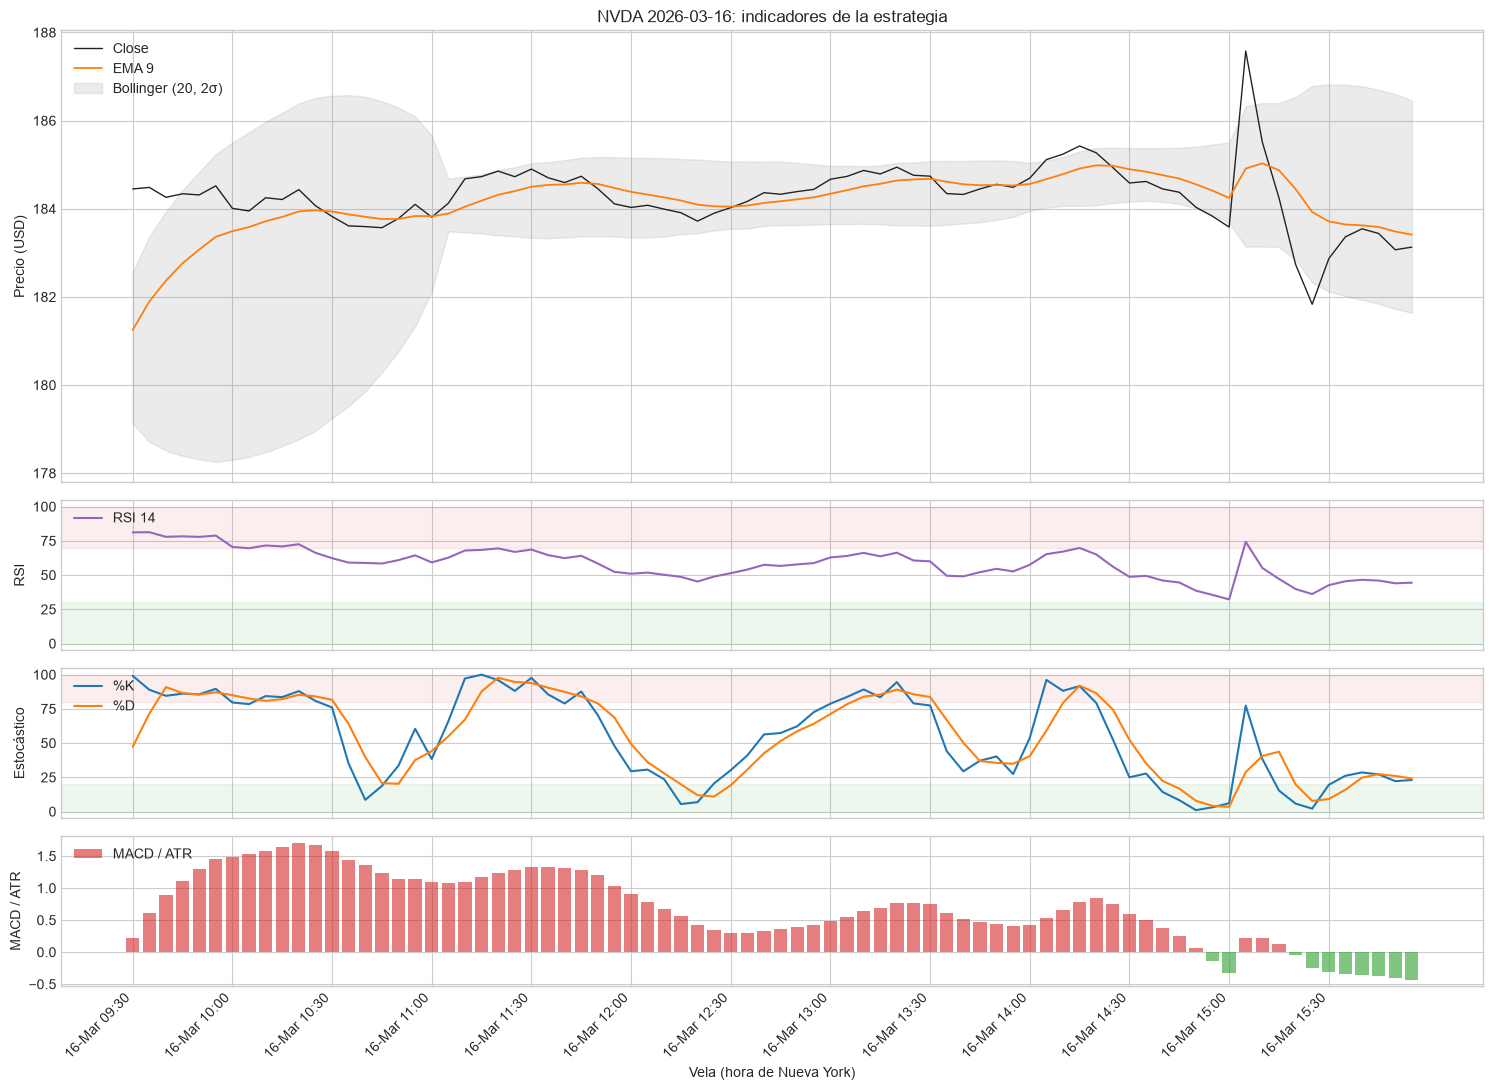

In [5]:
indicadores = calcular_indicadores(train, PARAMETROS_BASE)
plot_indicadores(indicadores.loc[DIA_EJEMPLO], titulo=f"NVDA {DIA_EJEMPLO}: indicadores de la estrategia")
plt.show()

## 3. Señales: 2 de 3 votos + gatillo EMA 9

In [6]:
senales = generar_senales(train)
senales.loc[senales["senal"] != 0, ["Close", "bb_low", "bb_high", "rsi_14", "stoch_k", "macd_atr", "ema_9",
                                    "volatilidad", "momento", "tendencia", "gatillo_ema", "senal"]].head(10).round(2)

,Close,bb_low,bb_high,rsi_14,stoch_k,macd_atr,ema_9,volatilidad,momento,tendencia,gatillo_ema,senal
Datetime,,,,,,,,,,,,
2026-01-06 10:30:00-05:00,190.85,186.62,193.26,61.04,71.05,1.36,191.04,0,-1,-1,-1,-1
2026-01-07 10:35:00-05:00,189.22,186.17,191.88,50.55,55.20,0.87,190.08,0,-1,-1,-1,-1
2026-01-08 12:45:00-05:00,184.50,183.96,185.37,41.08,41.05,-1.08,184.41,0,1,1,1,1
2026-01-15 10:25:00-05:00,187.60,180.20,191.49,67.58,77.56,2.08,187.70,0,-1,-1,-1,-1
2026-01-15 10:40:00-05:00,187.49,181.81,191.56,62.42,34.31,1.76,187.76,0,-1,-1,-1,-1
2026-01-15 12:15:00-05:00,188.44,186.88,189.24,59.48,56.38,1.18,188.56,0,-1,-1,-1,-1
2026-01-16 09:30:00-05:00,189.28,186.57,189.55,63.78,88.41,-0.46,187.76,0,1,1,1,1
2026-01-20 10:25:00-05:00,180.79,176.17,190.29,28.33,15.18,-2.55,180.77,0,1,1,1,1
2026-01-20 12:55:00-05:00,179.80,179.38,180.37,40.17,55.79,-1.09,179.73,0,1,1,1,1


In [7]:
pd.DataFrame({
    modo: generar_senales(train, modo=modo)["senal"].value_counts().reindex([1, -1], fill_value=0)
    for modo in MODOS
}).rename(index={1: "compras", -1: "ventas"})

,dos_de_tres,estricta,solo_bollinger,solo_momento,solo_macd
senal,,,,,
compras,36,5,49,54,134
ventas,43,2,37,73,157


## 4. Backtest con parámetros base

In [8]:
resultado_base = ejecutar_backtest(senales)
resultado_base["operaciones"].head(10).round(2)

/var/folders/pk/r0skg4n15qn2ngdpl5bhng2w0000gn/T/ipykernel_65604/1983892240.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  resultado_base["operaciones"].head(10).round(2)


,direccion,entrada,precio_entrada,acciones,sl,tp,costos,deslizamiento,enfriamiento,salida,precio_salida,motivo,pnl
0,-1,2026-01-06 10:35:00-05:00,190.82,5234.12,191.96,189.39,2487.84,463.23,0,2026-01-06 10:50:00-05:00,189.43,take-profit,4969.65
1,-1,2026-01-07 10:40:00-05:00,189.18,5304.33,190.43,187.63,2517.30,523.71,0,2026-01-07 10:45:00-05:00,190.48,stop-loss,-9119.24
2,1,2026-01-08 12:50:00-05:00,184.53,5387.20,183.78,185.47,2480.00,307.76,0,2026-01-08 14:20:00-05:00,183.75,stop-loss,-6553.35
3,-1,2026-01-15 10:30:00-05:00,187.55,5264.77,188.74,186.08,2476.58,436.42,0,2026-01-15 11:50:00-05:00,188.77,stop-loss,-8708.39
4,-1,2026-01-15 12:20:00-05:00,188.40,5194.06,189.24,187.34,2452.04,323.46,0,2026-01-15 13:30:00-05:00,189.27,stop-loss,-6864.45
5,1,2026-01-20 10:30:00-05:00,180.83,5372.73,179.61,182.34,2420.43,455.61,0,2026-01-20 11:50:00-05:00,179.58,stop-loss,-8952.42
6,1,2026-01-20 13:00:00-05:00,179.83,5351.72,179.12,180.70,2401.08,303.26,0,2026-01-20 13:35:00-05:00,179.10,stop-loss,-6187.55
7,-1,2026-01-21 15:30:00-05:00,183.74,5203.29,184.63,182.64,2396.22,377.80,0,2026-01-21 15:35:00-05:00,184.67,stop-loss,-7028.06
8,-1,2026-01-27 12:45:00-05:00,189.61,5004.22,190.12,188.98,2368.35,220.86,0,2026-01-27 13:00:00-05:00,189.00,take-profit,784.41
9,1,2026-01-28 12:05:00-05:00,190.84,4975.53,190.06,191.81,2379.71,275.80,0,2026-01-28 13:30:00-05:00,191.78,take-profit,2430.34


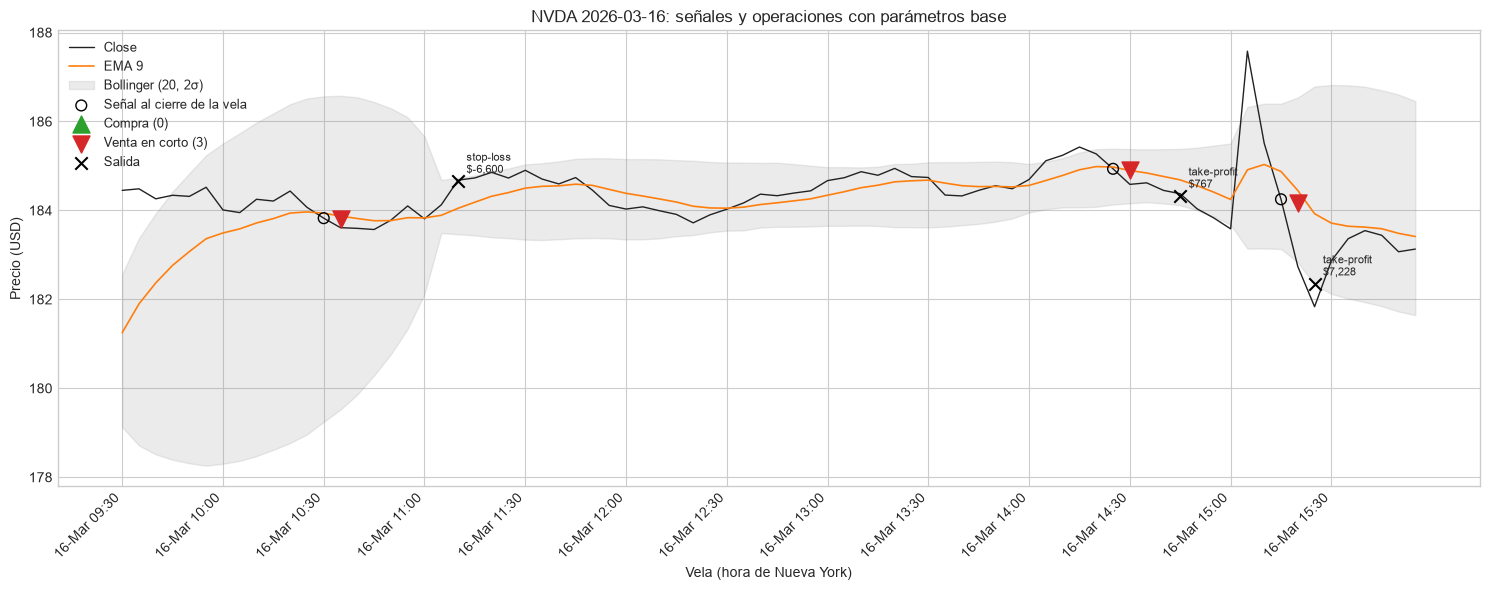

In [9]:
plot_operaciones(senales.loc[DIA_EJEMPLO], resultado_base["operaciones"], titulo=f"NVDA {DIA_EJEMPLO}: señales y operaciones con parámetros base")
plt.show()

## 5. Espacio de búsqueda de θ

In [10]:
pd.DataFrame([{"parámetro": k, "mínimo": v[0], "máximo": v[1], "justificación": v[3]} for k, v in RANGOS.items()]).set_index("parámetro")

,mínimo,máximo,justificación
parámetro,,,
bb_n,14.00,30.0,alrededor de las 20 velas de la gráfica: de 70...
bb_k,1.50,3.0,de bandas estrechas (más señales) a solo movim...
rsi_bajo,20.00,40.0,umbral de sobreventa alrededor de 30; sobrecom...
sto_bajo,10.00,30.0,zona del Estocástico alrededor de 20; alta = 1...
macd_umbral,0.30,1.5,MACD en múltiplos de ATR: de desviación leve a...
ema_n,5.00,15.0,gatillo alrededor de la EMA 9: de reacción ráp...
memoria,1.00,12.0,de 5 min a 1 h para que preparación y gatillo ...
sl_atr,1.00,4.0,stop entre 1 y 4 rangos típicos de vela
tp_atr,2.00,8.0,objetivo que supere el costo de 0.25% ida y vu...


In [11]:
print(f"Restricción: menos de {MIN_OPERACIONES} operaciones por régimen en la ventana → Calmar = −10")

Restricción: menos de 10 operaciones por régimen en la ventana → Calmar = −10


## 6. Random search contra TPE

In [12]:
diag = pd.DataFrame(resumen["diagnostico"]).T
diag[["n_random", "mejor_random", "n_tpe", "mejor_tpe", "meseta_tpe", "theta_es_argmax", "activo"]]

,n_random,mejor_random,n_tpe,mejor_tpe,meseta_tpe,theta_es_argmax,activo
tendencia,200,-0.05591,200,-2.557408,-3.189612,False,False
reversion,200,13.900489,200,59.384284,56.708756,False,True
crisis,200,-4.630565,200,11.680446,8.722895,False,True


In [13]:
for regimen, d in resumen["diagnostico"].items():
    print(f"{regimen}: random search N = {d['n_random']} trials · TPE N = {d['n_tpe']} trials · "
          f"mejor Calmar TPE = {d['mejor_tpe']:.2f}")

tendencia: random search N = 200 trials · TPE N = 200 trials · mejor Calmar TPE = -2.56
reversion: random search N = 200 trials · TPE N = 200 trials · mejor Calmar TPE = 59.38
crisis: random search N = 200 trials · TPE N = 200 trials · mejor Calmar TPE = 11.68


Historia de optimización: valor del objetivo por trial y mejor acumulado.

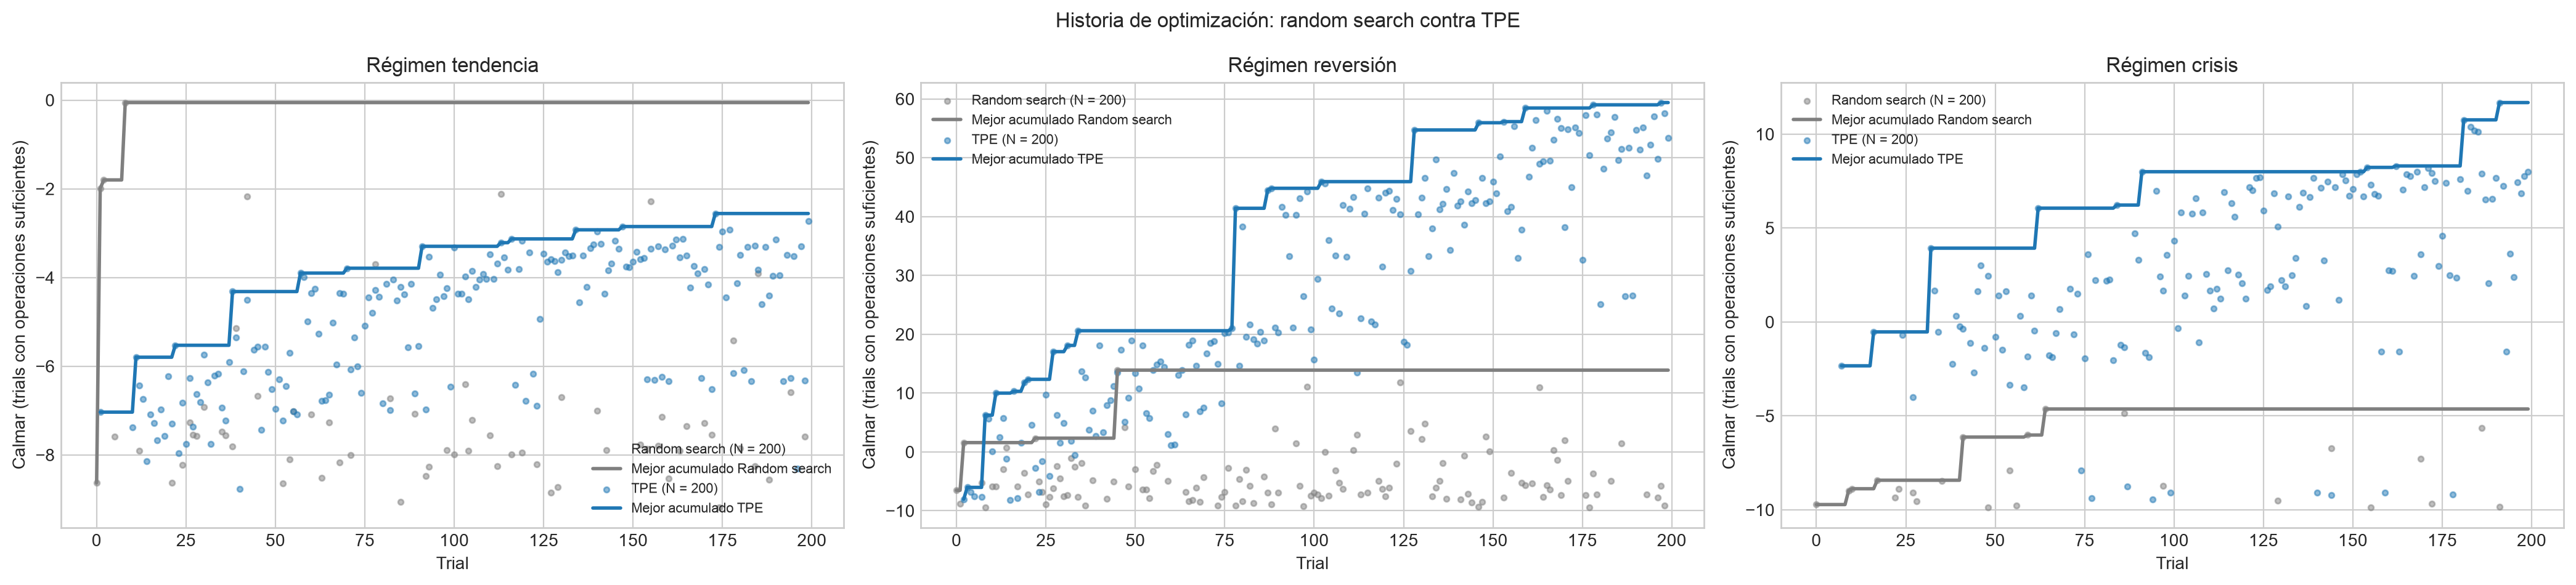

In [14]:
display(Image(FIG / "11_historia_optimizacion.png"))

Importancia de parámetros del TPE: define los ejes de la superficie 3D.

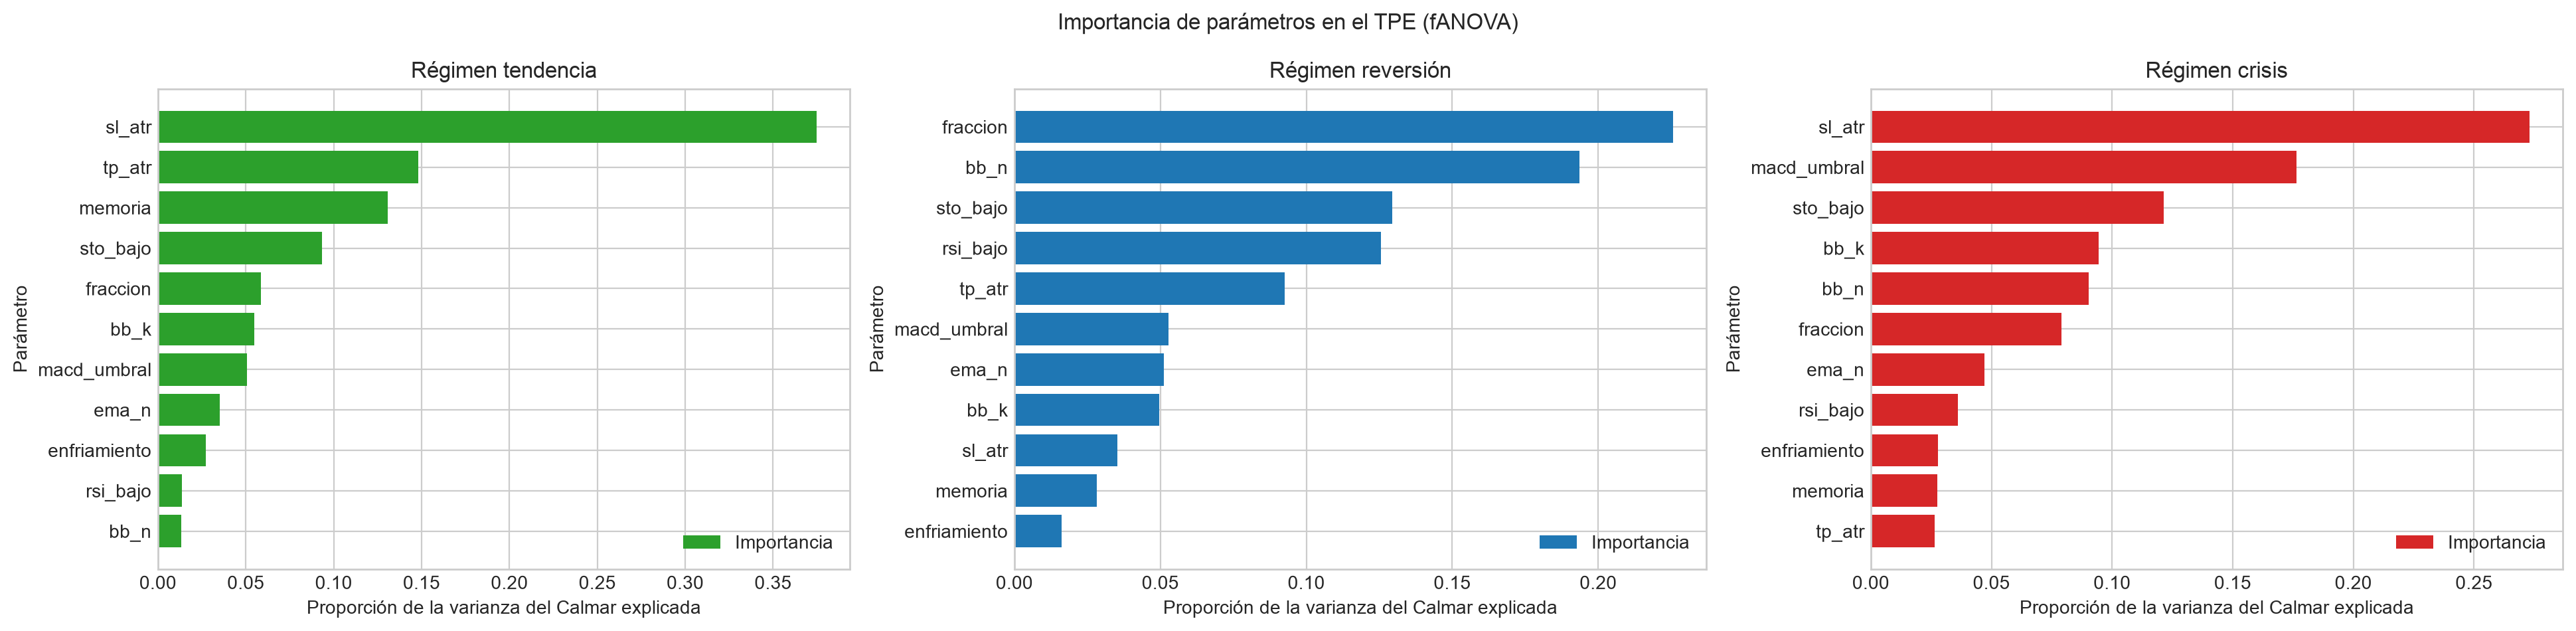

In [15]:
display(Image(FIG / "12_importancia_parametros.png"))

Superficie 3D del Calmar. No existe una superficie completa en más de 2 dimensiones, así que se toma un corte en las dos dimensiones más importantes según el TPE y el resto de θ se fija en el mejor punto del random search.

tendencia → ejes: ['sl_atr', 'tp_atr']


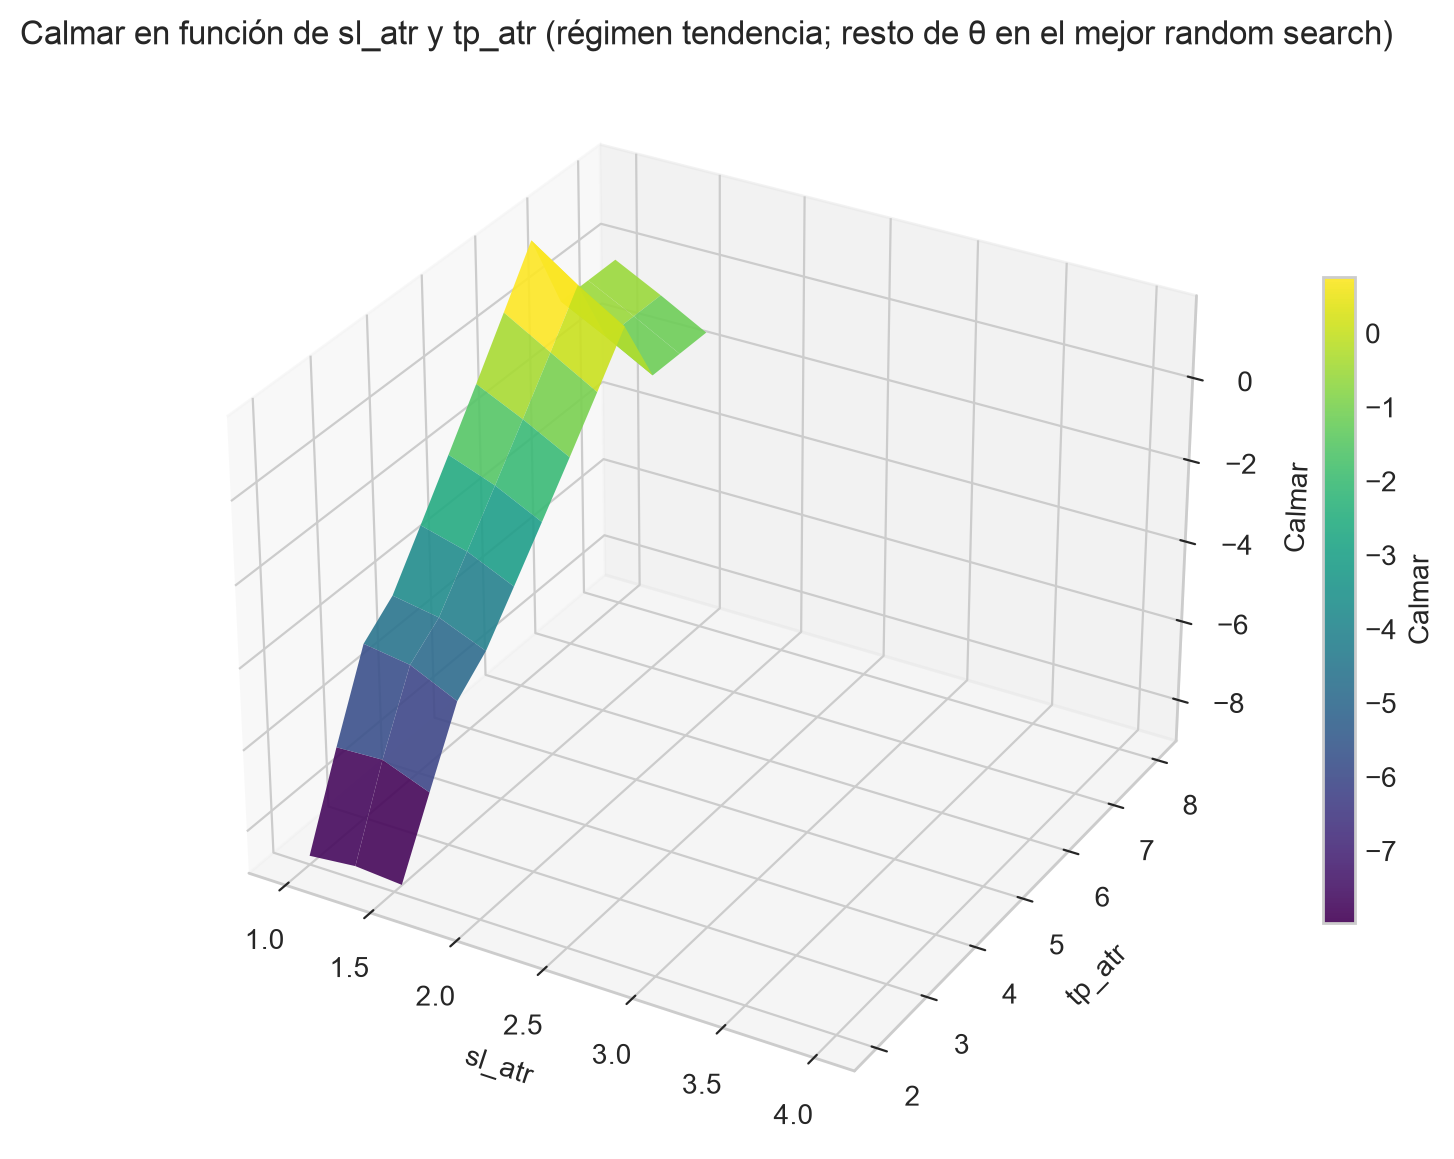

reversion → ejes: ['fraccion', 'bb_n']


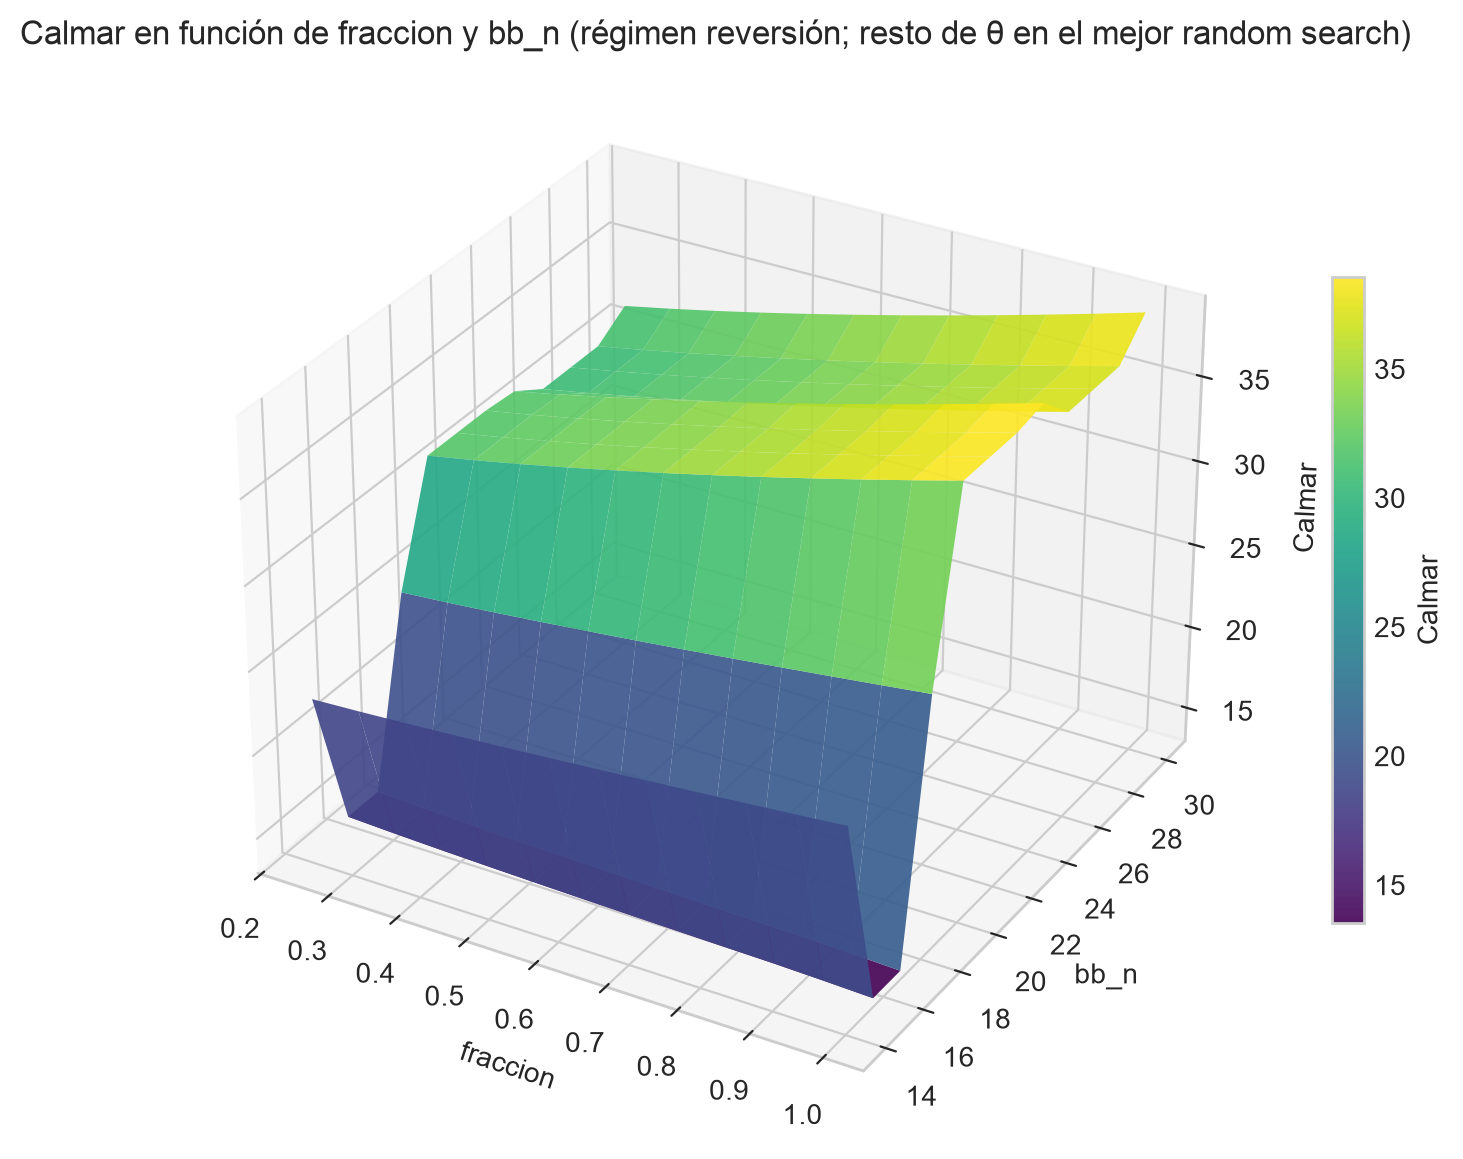

crisis → ejes: ['sl_atr', 'macd_umbral']


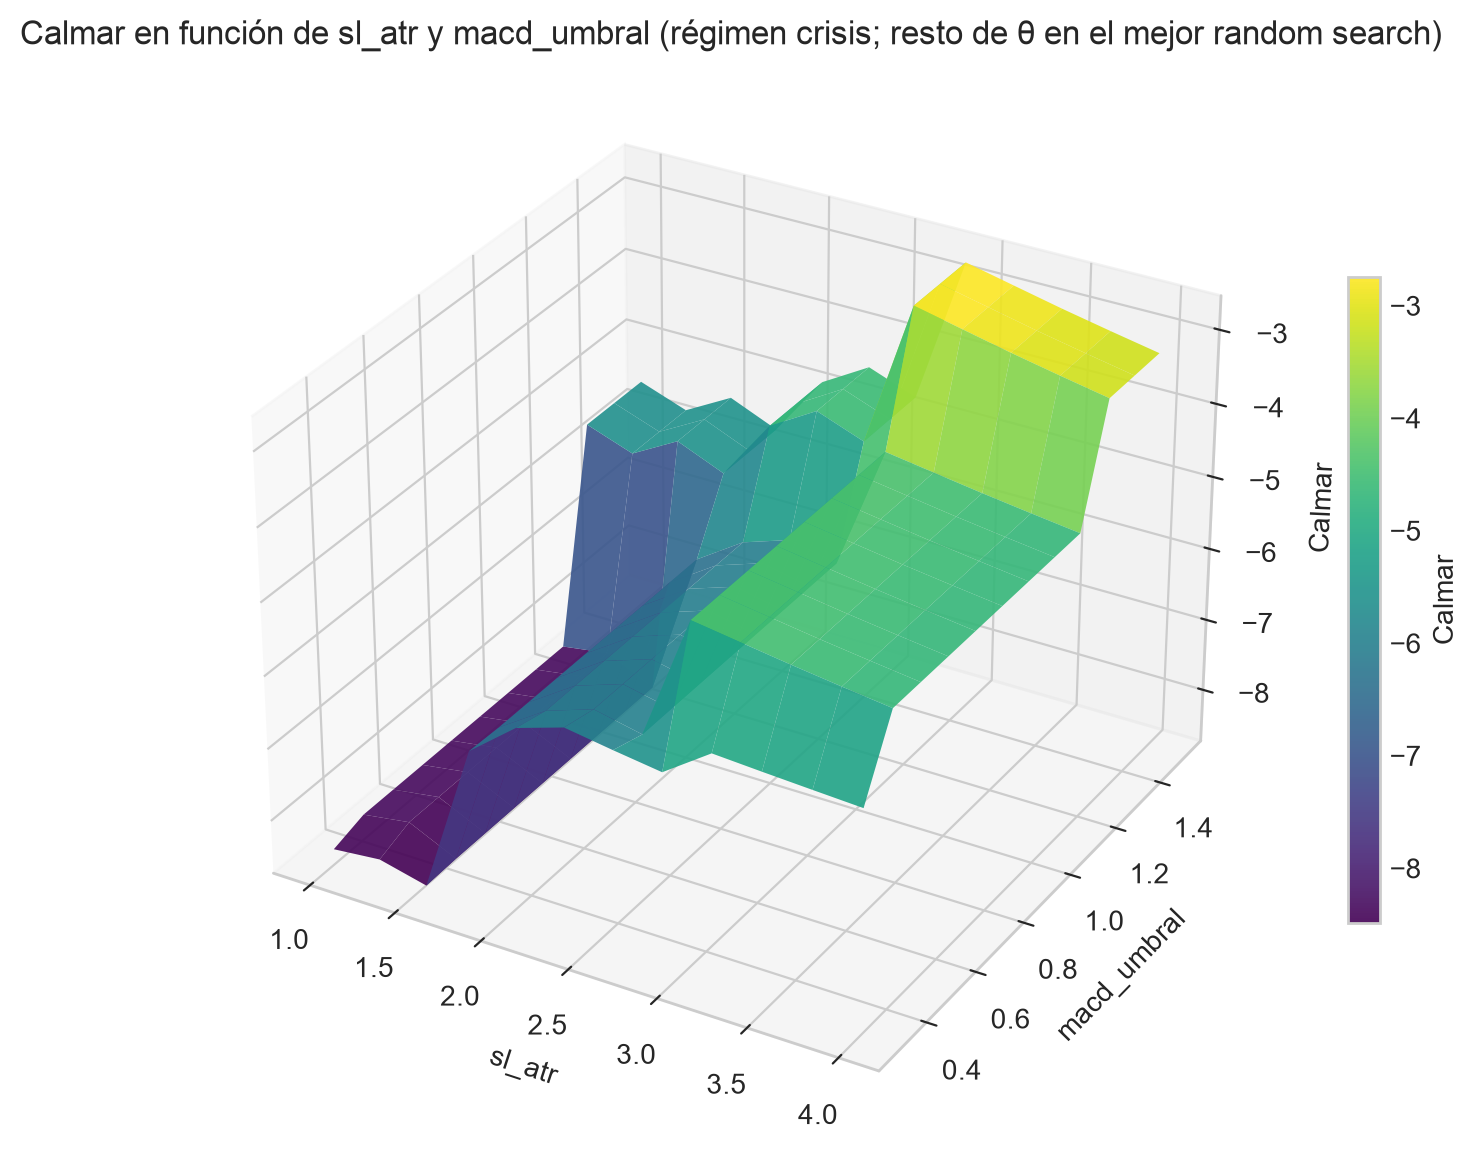

In [16]:
for regimen, d in resumen["diagnostico"].items():
    if "ejes_superficie" in d:
        print(regimen, "→ ejes:", d["ejes_superficie"])
        display(Image(FIG / f"14_superficie_{regimen}.png"))

Slice plots: si el argmax (línea roja) está aislado y sus vecinos dan resultados muy distintos, θ* se toma del centro de la mejor meseta (línea verde), definida como el trial cuyo vecindario de 10 trials tiene el Calmar promedio más alto.

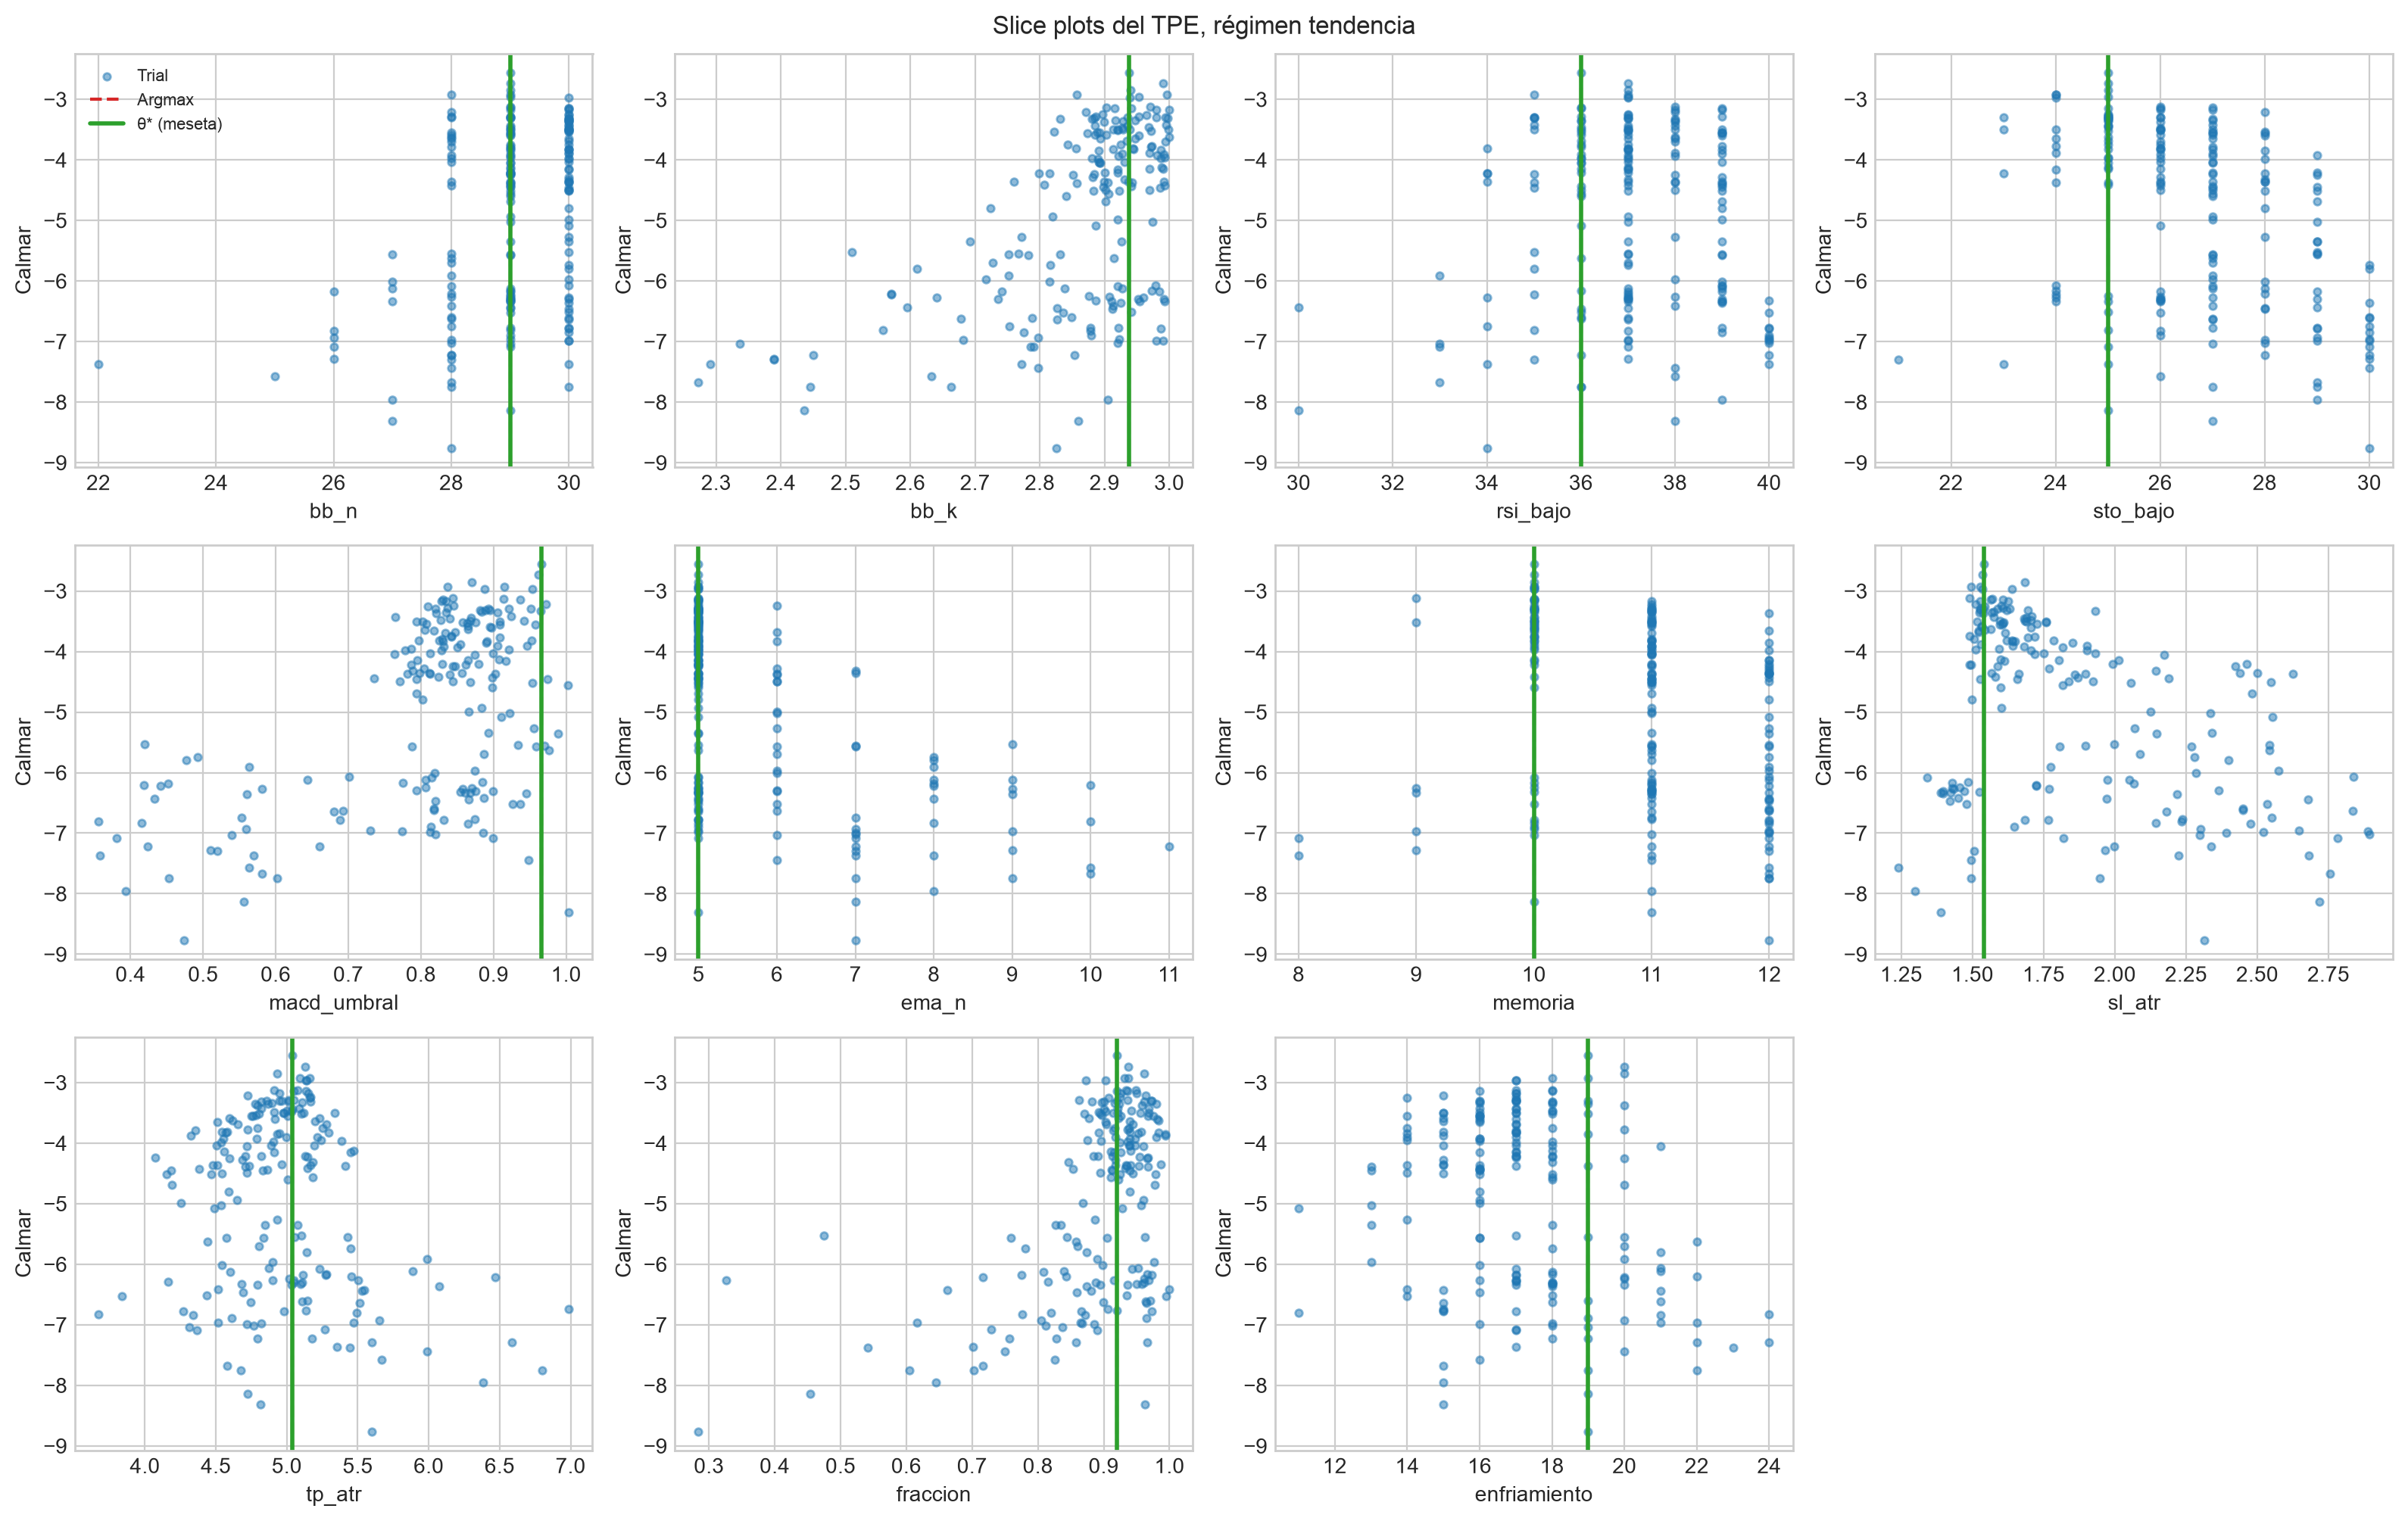

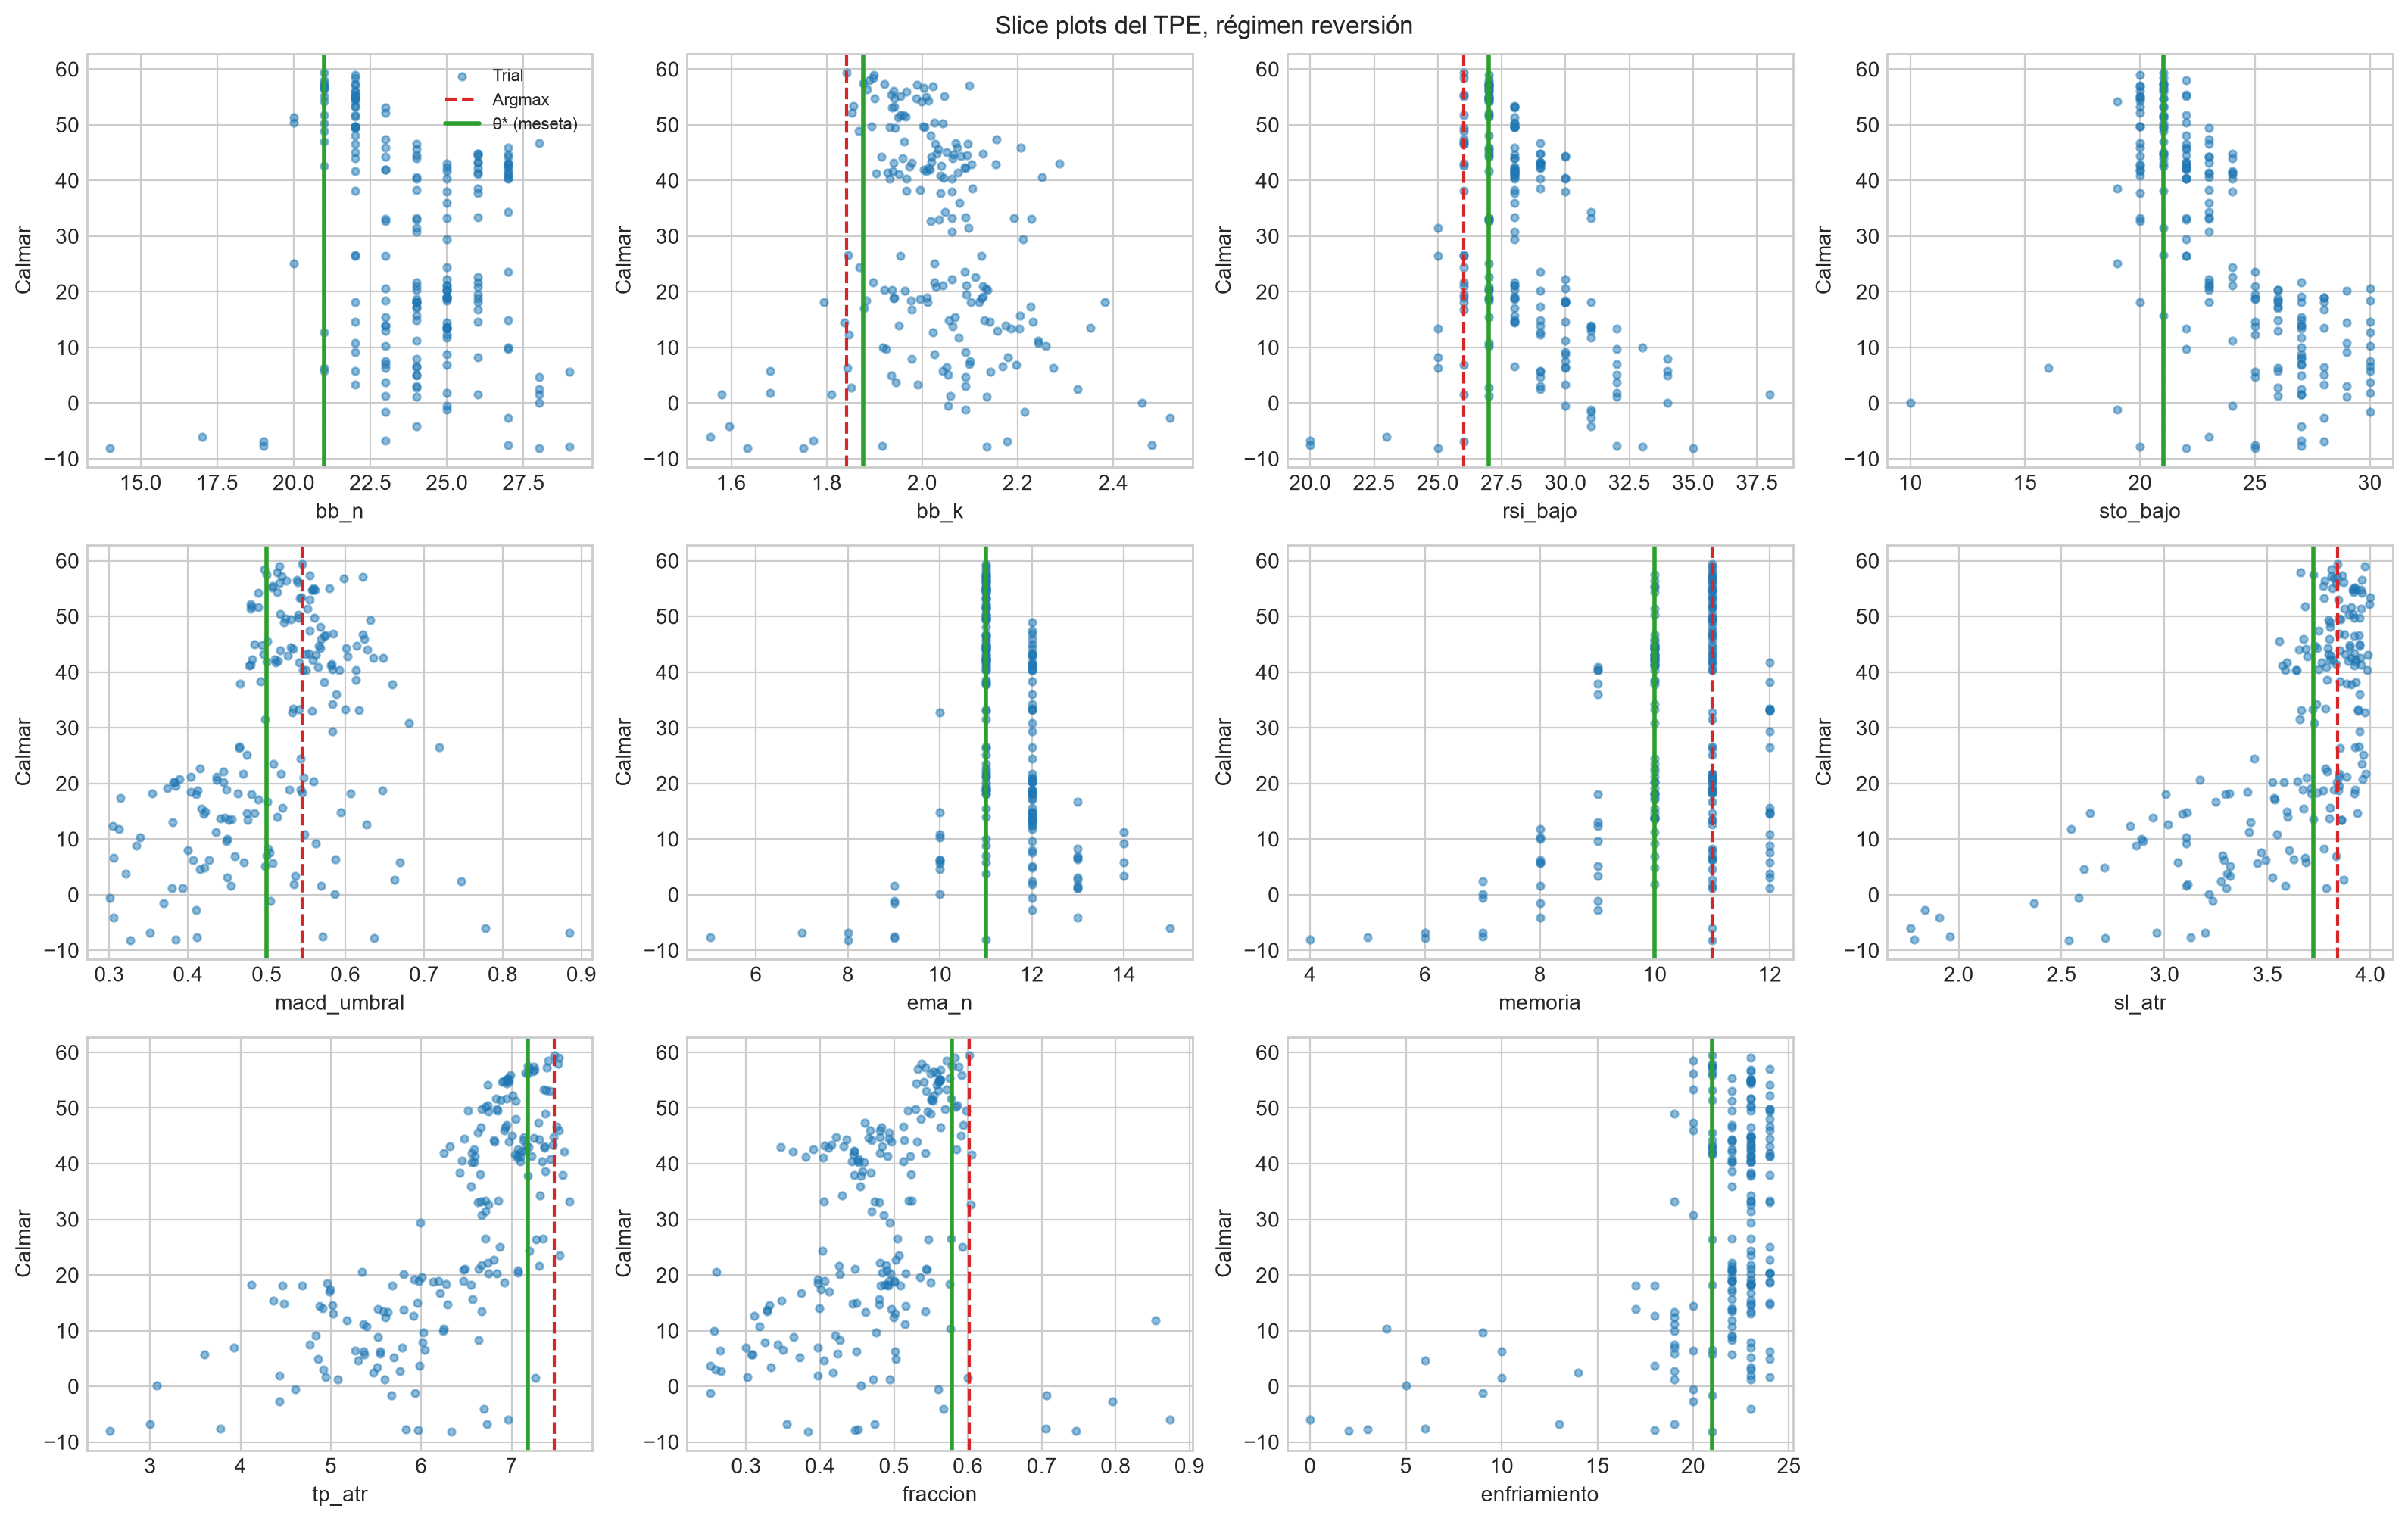

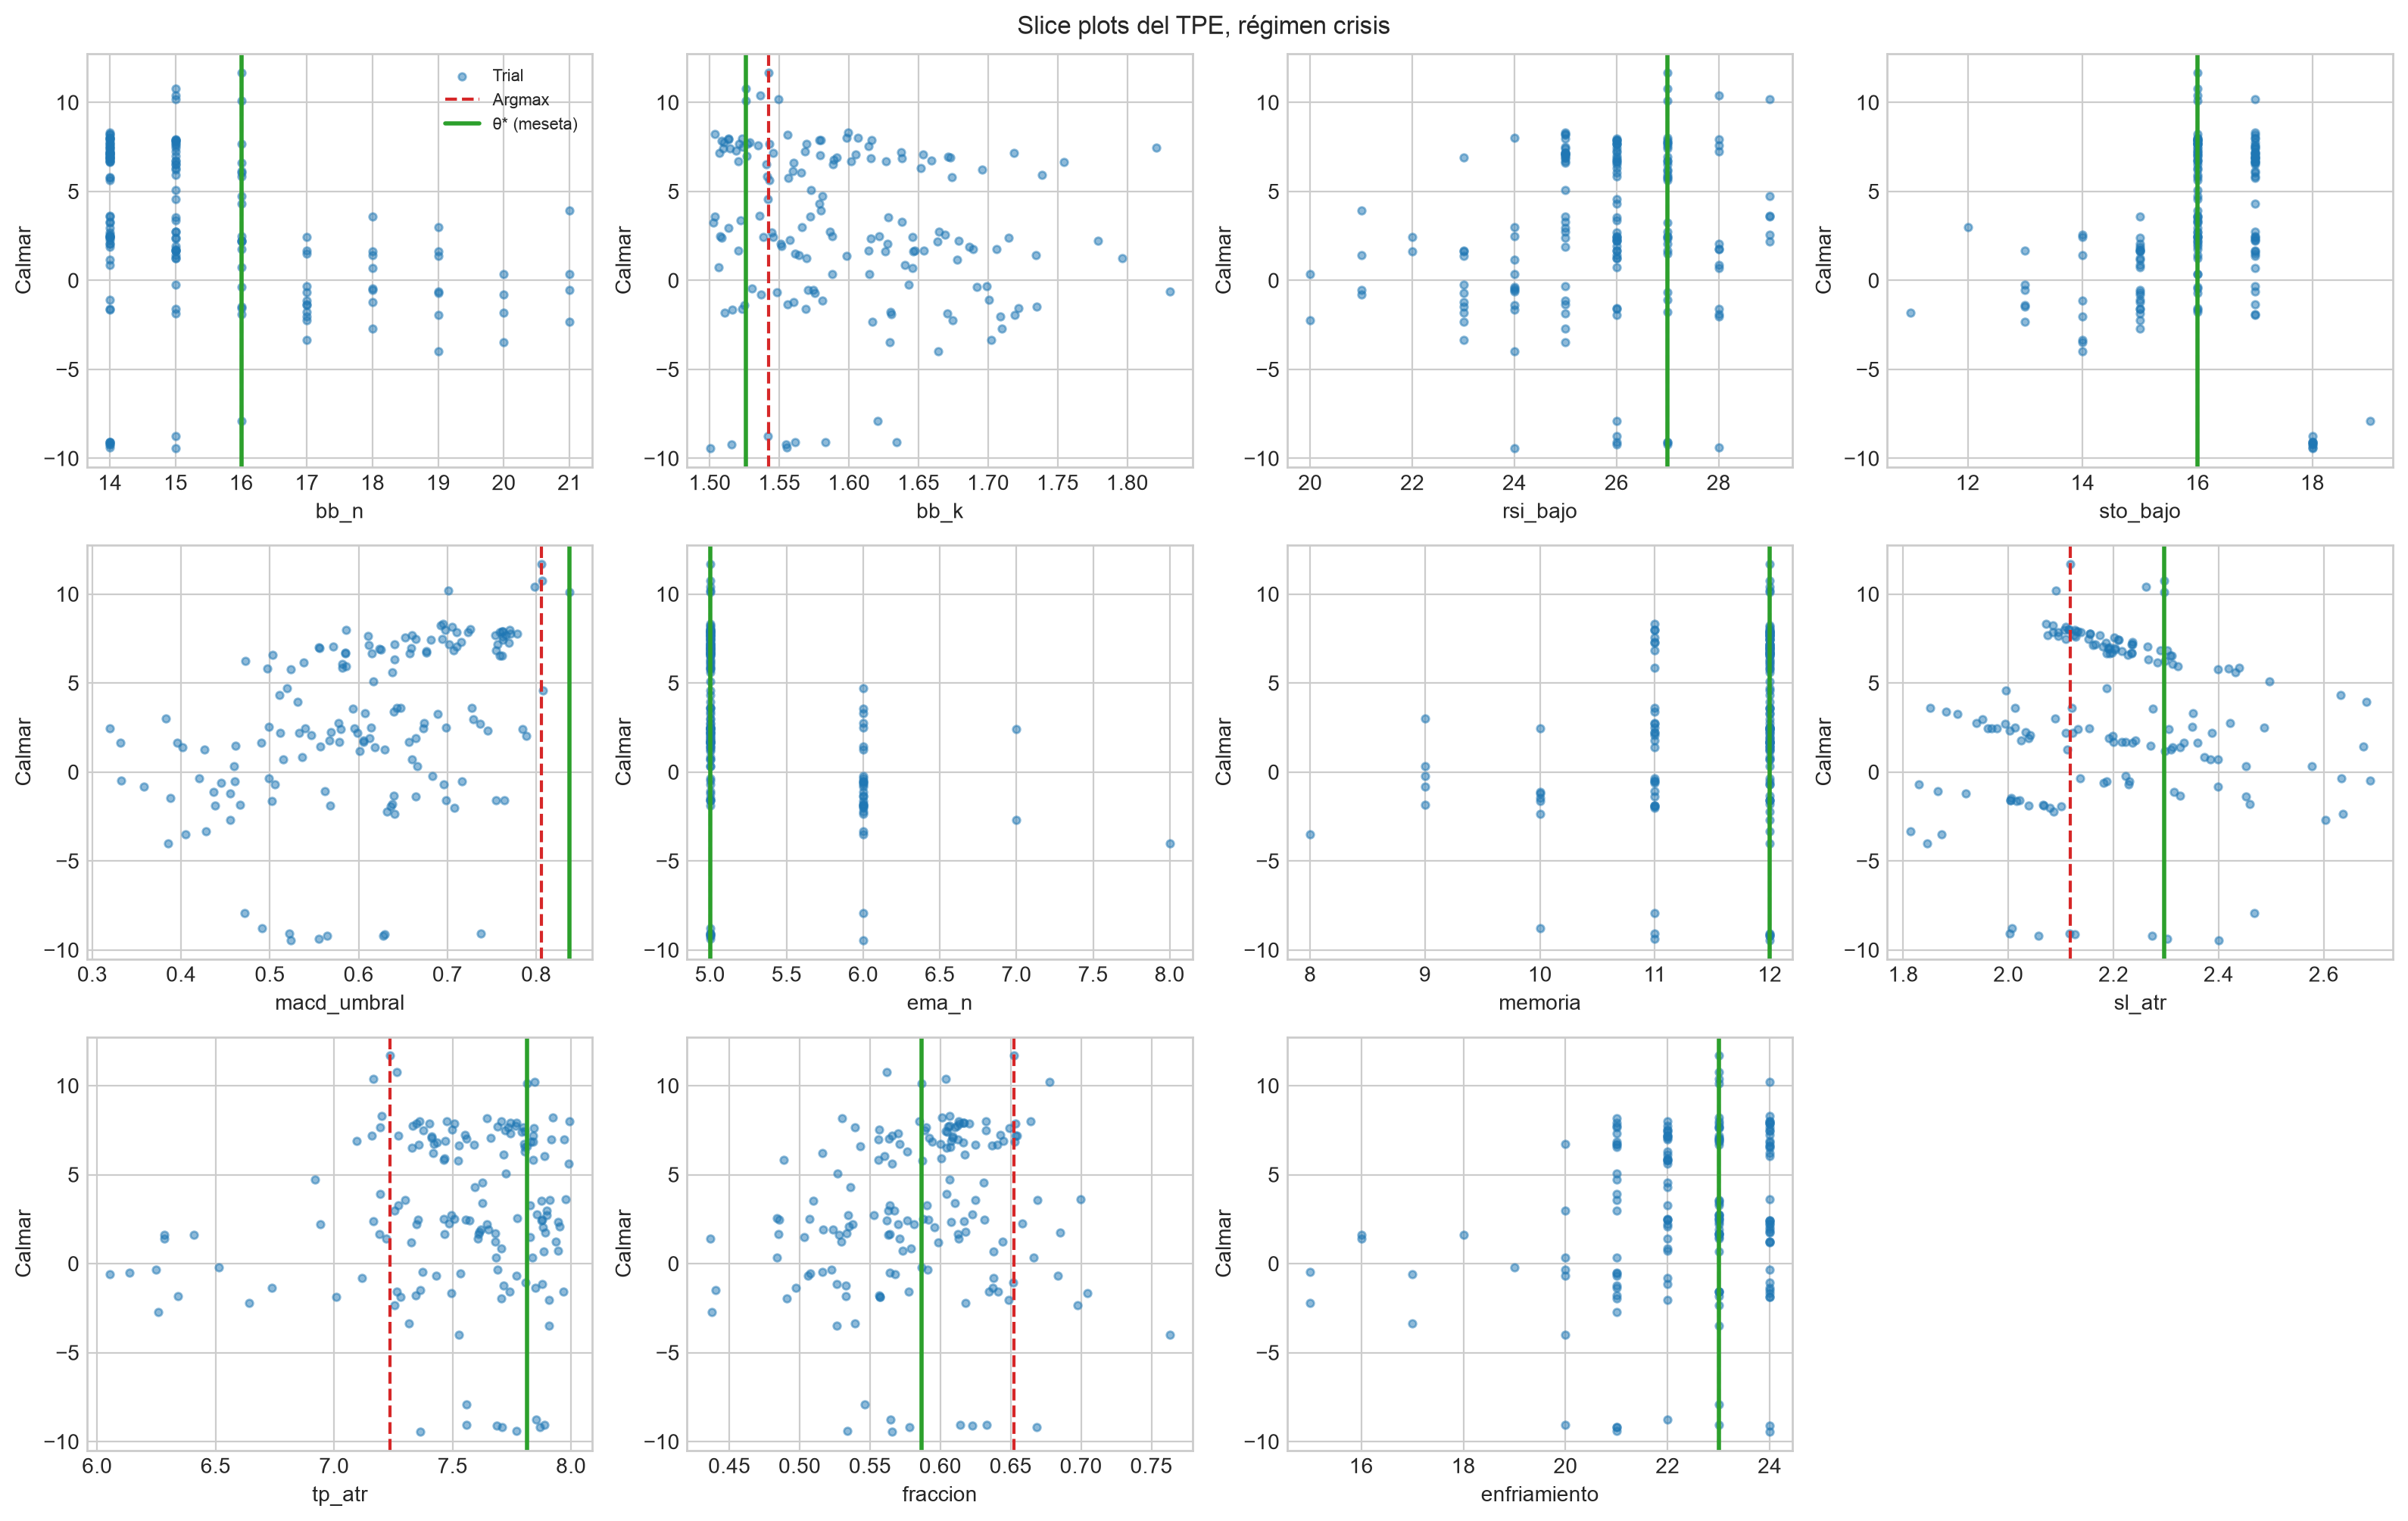

In [17]:
for regimen, d in resumen["diagnostico"].items():
    if "ejes_superficie" in d:
        display(Image(FIG / f"13_slices_{regimen}.png"))

## 7. Walk-forward: anchored contra rolling

In [18]:
wf = resumen["walk_forward"]
pd.DataFrame({
    modo: {"configuraciones": wf[f"configuraciones_{modo}"], "segundos": round(wf[f"segundos_{modo}"]),
           "anualizado dentro": wf[f"anualizado_dentro_{modo}"], "anualizado fuera": wf[f"anualizado_fuera_{modo}"],
           "retorno fuera": wf[f"retorno_fuera_{modo}"], "walk-forward efficiency": wf[f"eficiencia_{modo}"]}
    for modo in ("rolling", "anchored")
})

,rolling,anchored
configuraciones,10350.000000,11250.000000
segundos,315.000000,404.000000
anualizado dentro,0.553740,0.284746
anualizado fuera,-0.454788,-0.235962
retorno fuera,-0.250851,-0.120276
walk-forward efficiency,-0.821303,-0.828677


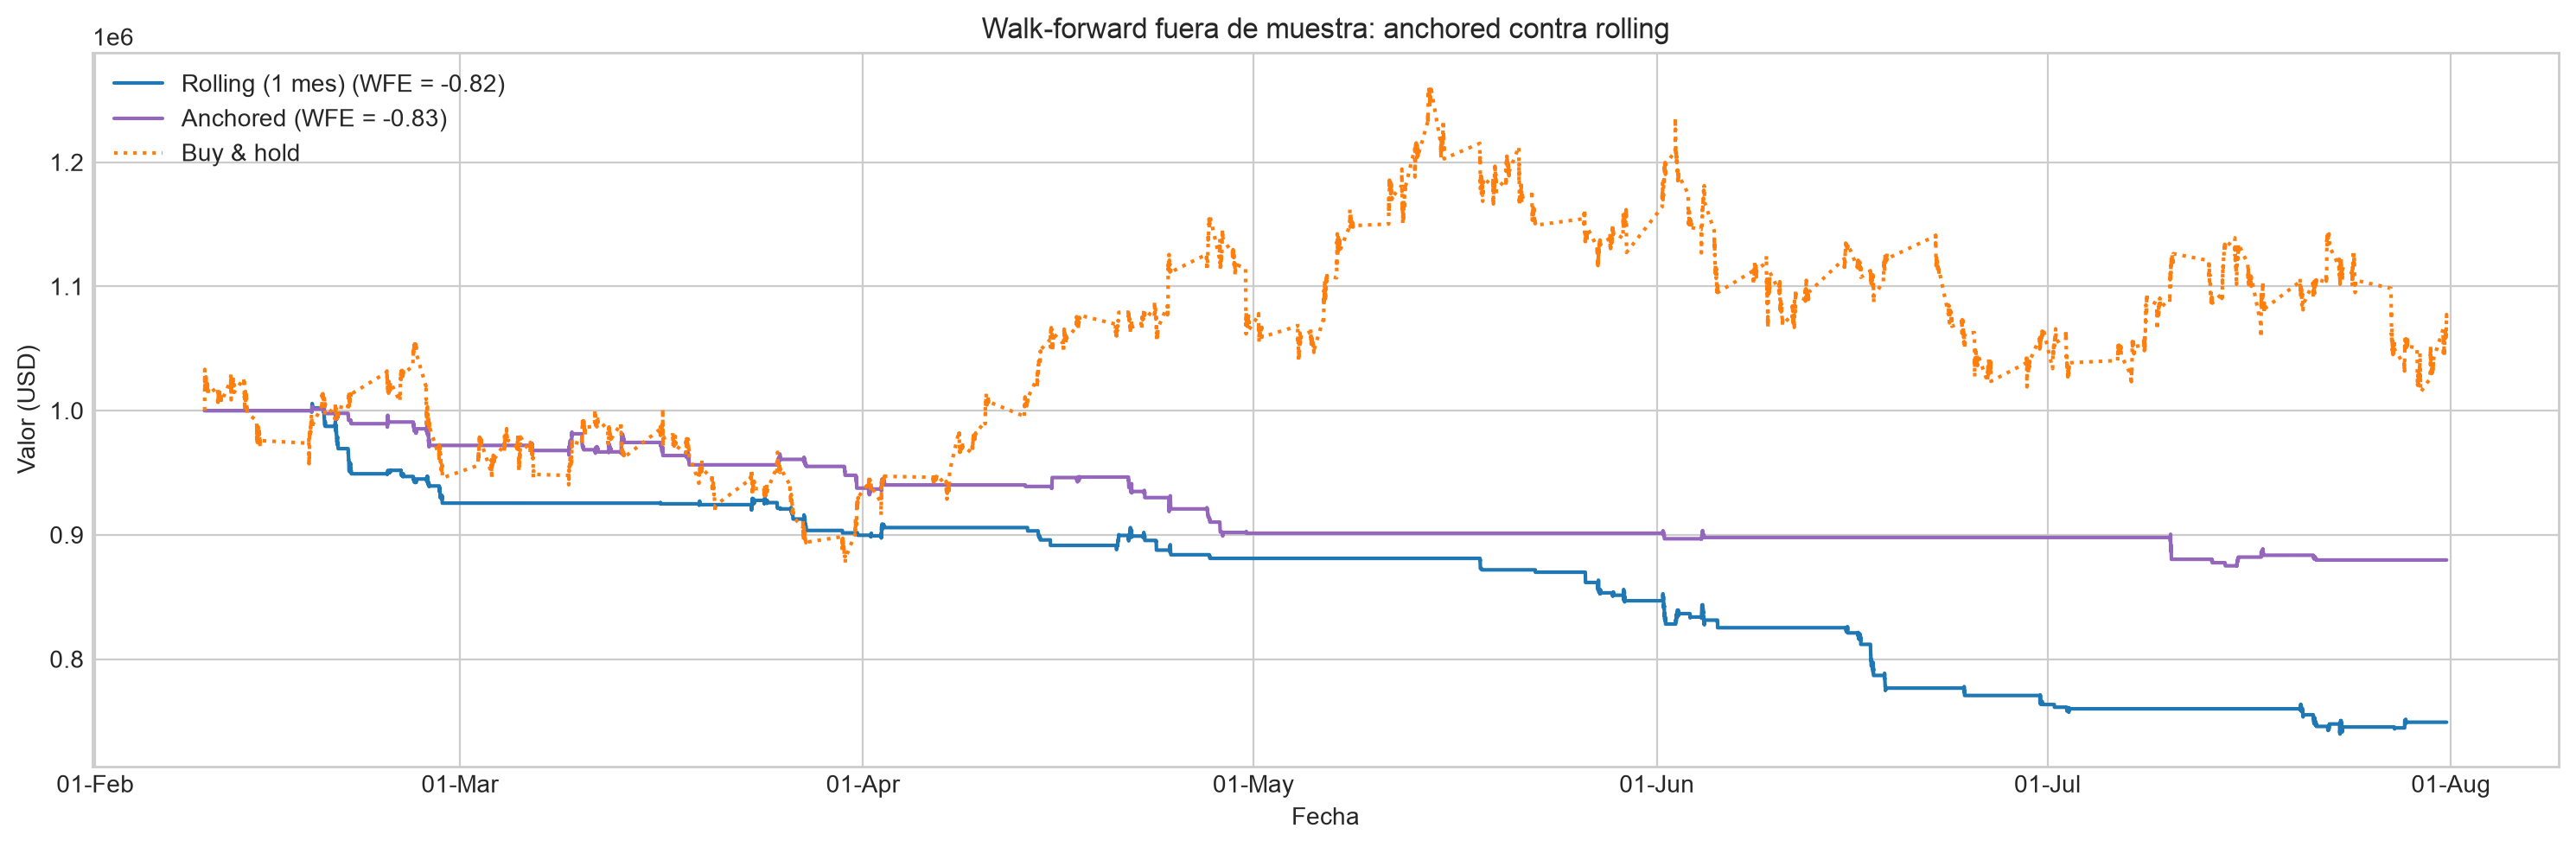

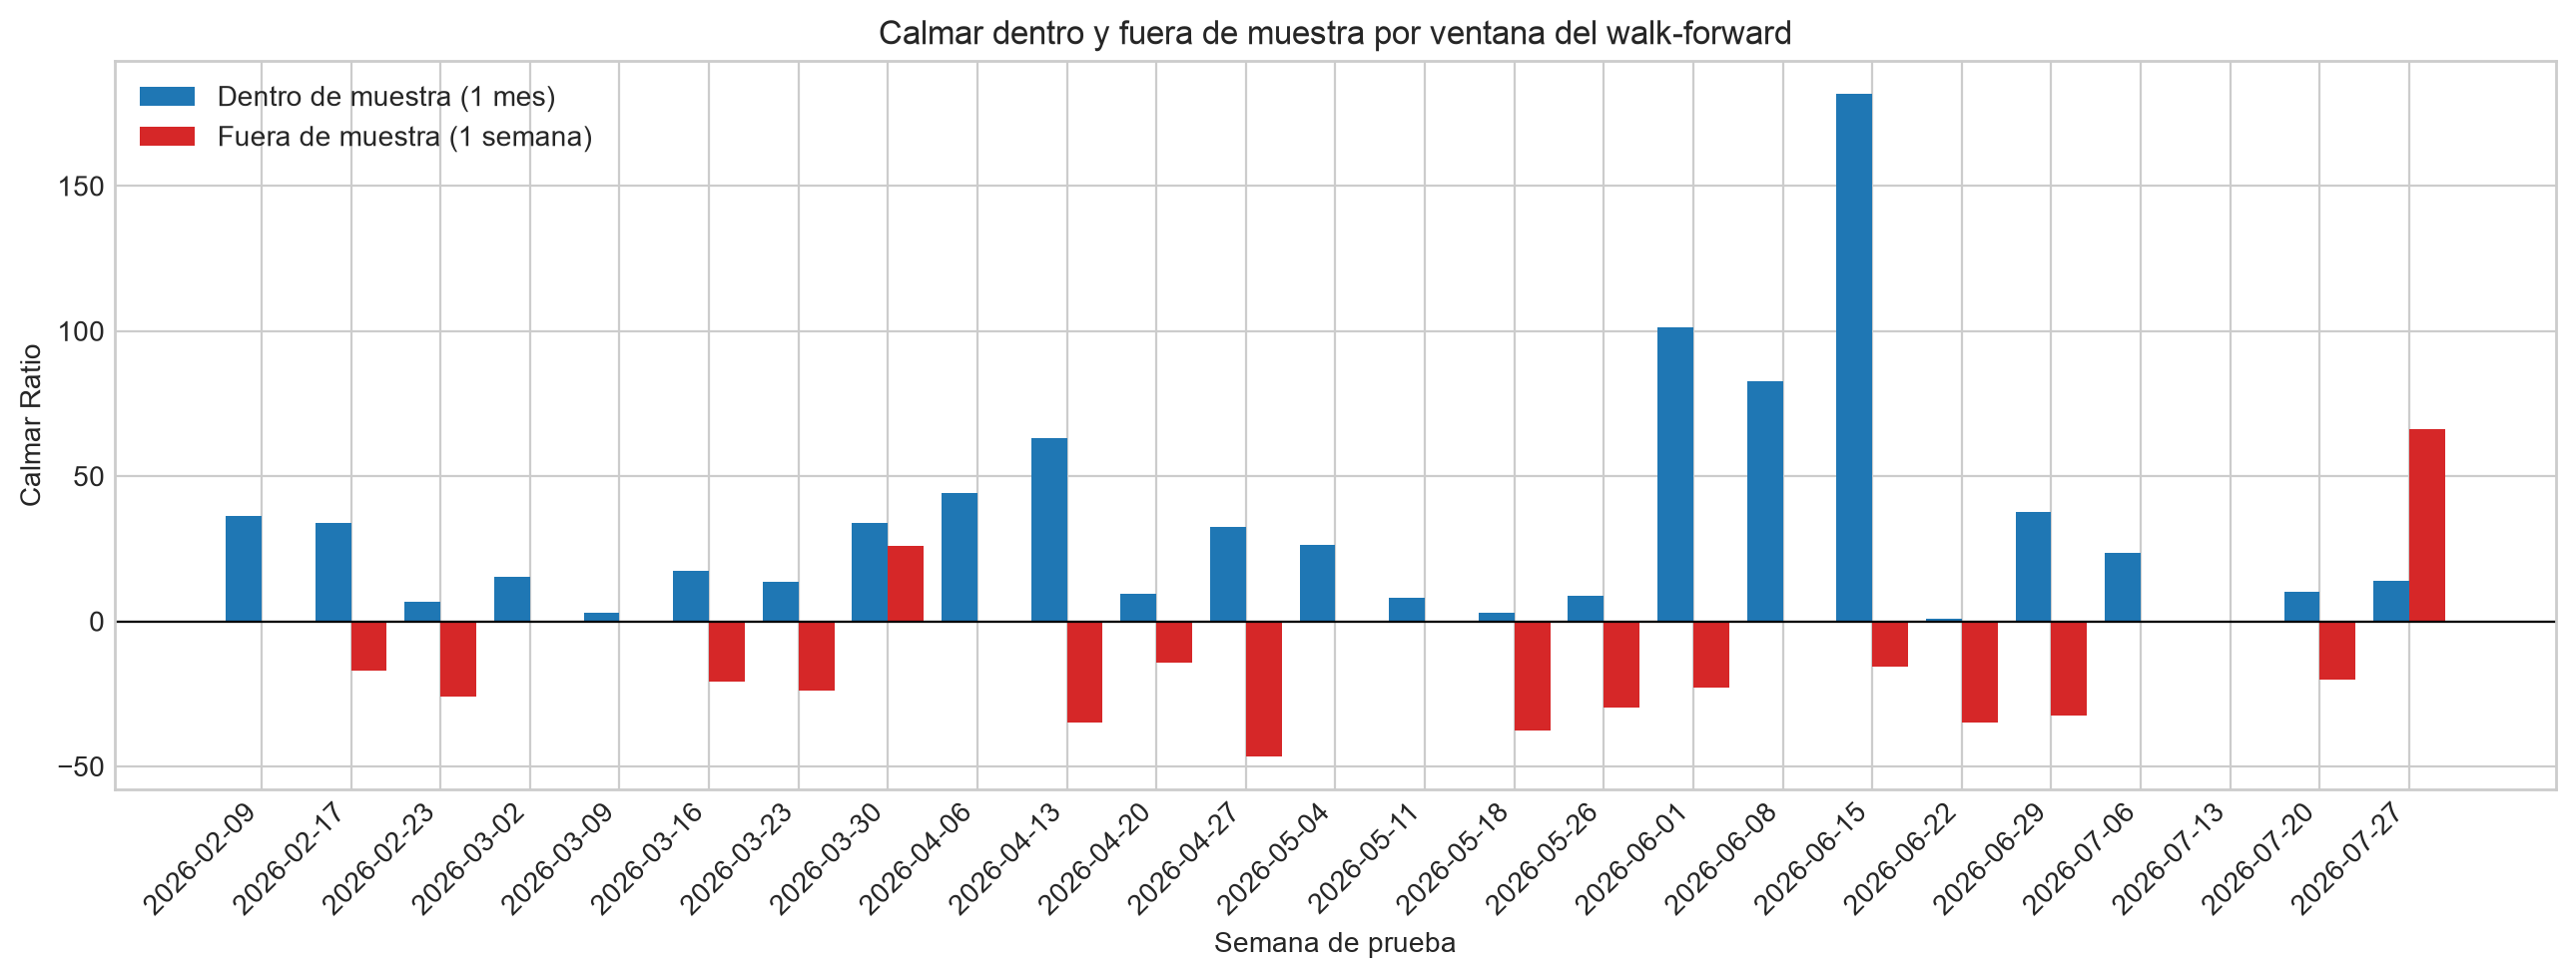

In [19]:
display(Image(FIG / "15_anchored_rolling.png"))
display(Image(FIG / "10_walk_forward.png"))

## 8. θ* congelado antes de tocar validation

In [20]:
theta = json.loads((PROJECT_ROOT / "docs" / "theta_congelado.json").read_text(encoding="utf-8"))
commit = subprocess.run(["git", "log", "-1", "--format=%H %ad %s", "--date=iso", "--", "docs/theta_congelado.json"],
                        cwd=PROJECT_ROOT, capture_output=True, text=True).stdout.strip()
print("Commit del congelamiento:", commit)
pd.DataFrame({r: p for r, p in theta["parametros"].items() if p is not None})

Commit del congelamiento: 9a11fab6634e00a0848a1defbce71a36763eead9 2026-09-29 01:57:20 -0600 Congela θ* con train + test antes de evaluar validation


,reversion,crisis
bb_n,21.000000,16.000000
bb_k,1.877259,1.525993
rsi_bajo,27.000000,27.000000
sto_bajo,21.000000,16.000000
macd_umbral,0.500176,0.837503
ema_n,11.000000,5.000000
memoria,10.000000,12.000000
sl_atr,3.722253,2.296868
tp_atr,7.180256,7.813295
fraccion,0.578756,0.586500


## 9. Métricas por conjunto

In [21]:
metricas = pd.read_csv(RES / "metricas.csv", index_col=0)
metricas.round(4)

,train (WF),B&H train,test (WF),B&H test,validation,B&H validation
retorno_total,-0.1531,0.1273,-0.1155,-0.0788,-0.0723,0.1284
rendimiento_anualizado,-0.4195,0.4804,-0.5129,-0.3818,-0.3842,1.1828
volatilidad,0.0698,0.3599,0.0986,0.3832,0.0651,0.3520
sharpe,-7.7539,1.2700,-7.2430,-1.0631,-7.4101,2.3924
sortino,-9.6522,1.8318,-9.0140,-1.4393,-9.4881,3.8384
calmar,-2.6414,2.8585,-3.8712,-2.1354,-5.3166,10.9100
max_drawdown,-0.1588,-0.1681,-0.1325,-0.1788,-0.0723,-0.1084
win_rate,0.2344,NaN,0.1935,NaN,0.3529,NaN
payoff,0.5949,NaN,1.1245,NaN,0.4806,NaN
operaciones,64.0000,0.0000,31.0000,0.0000,34.0000,0.0000


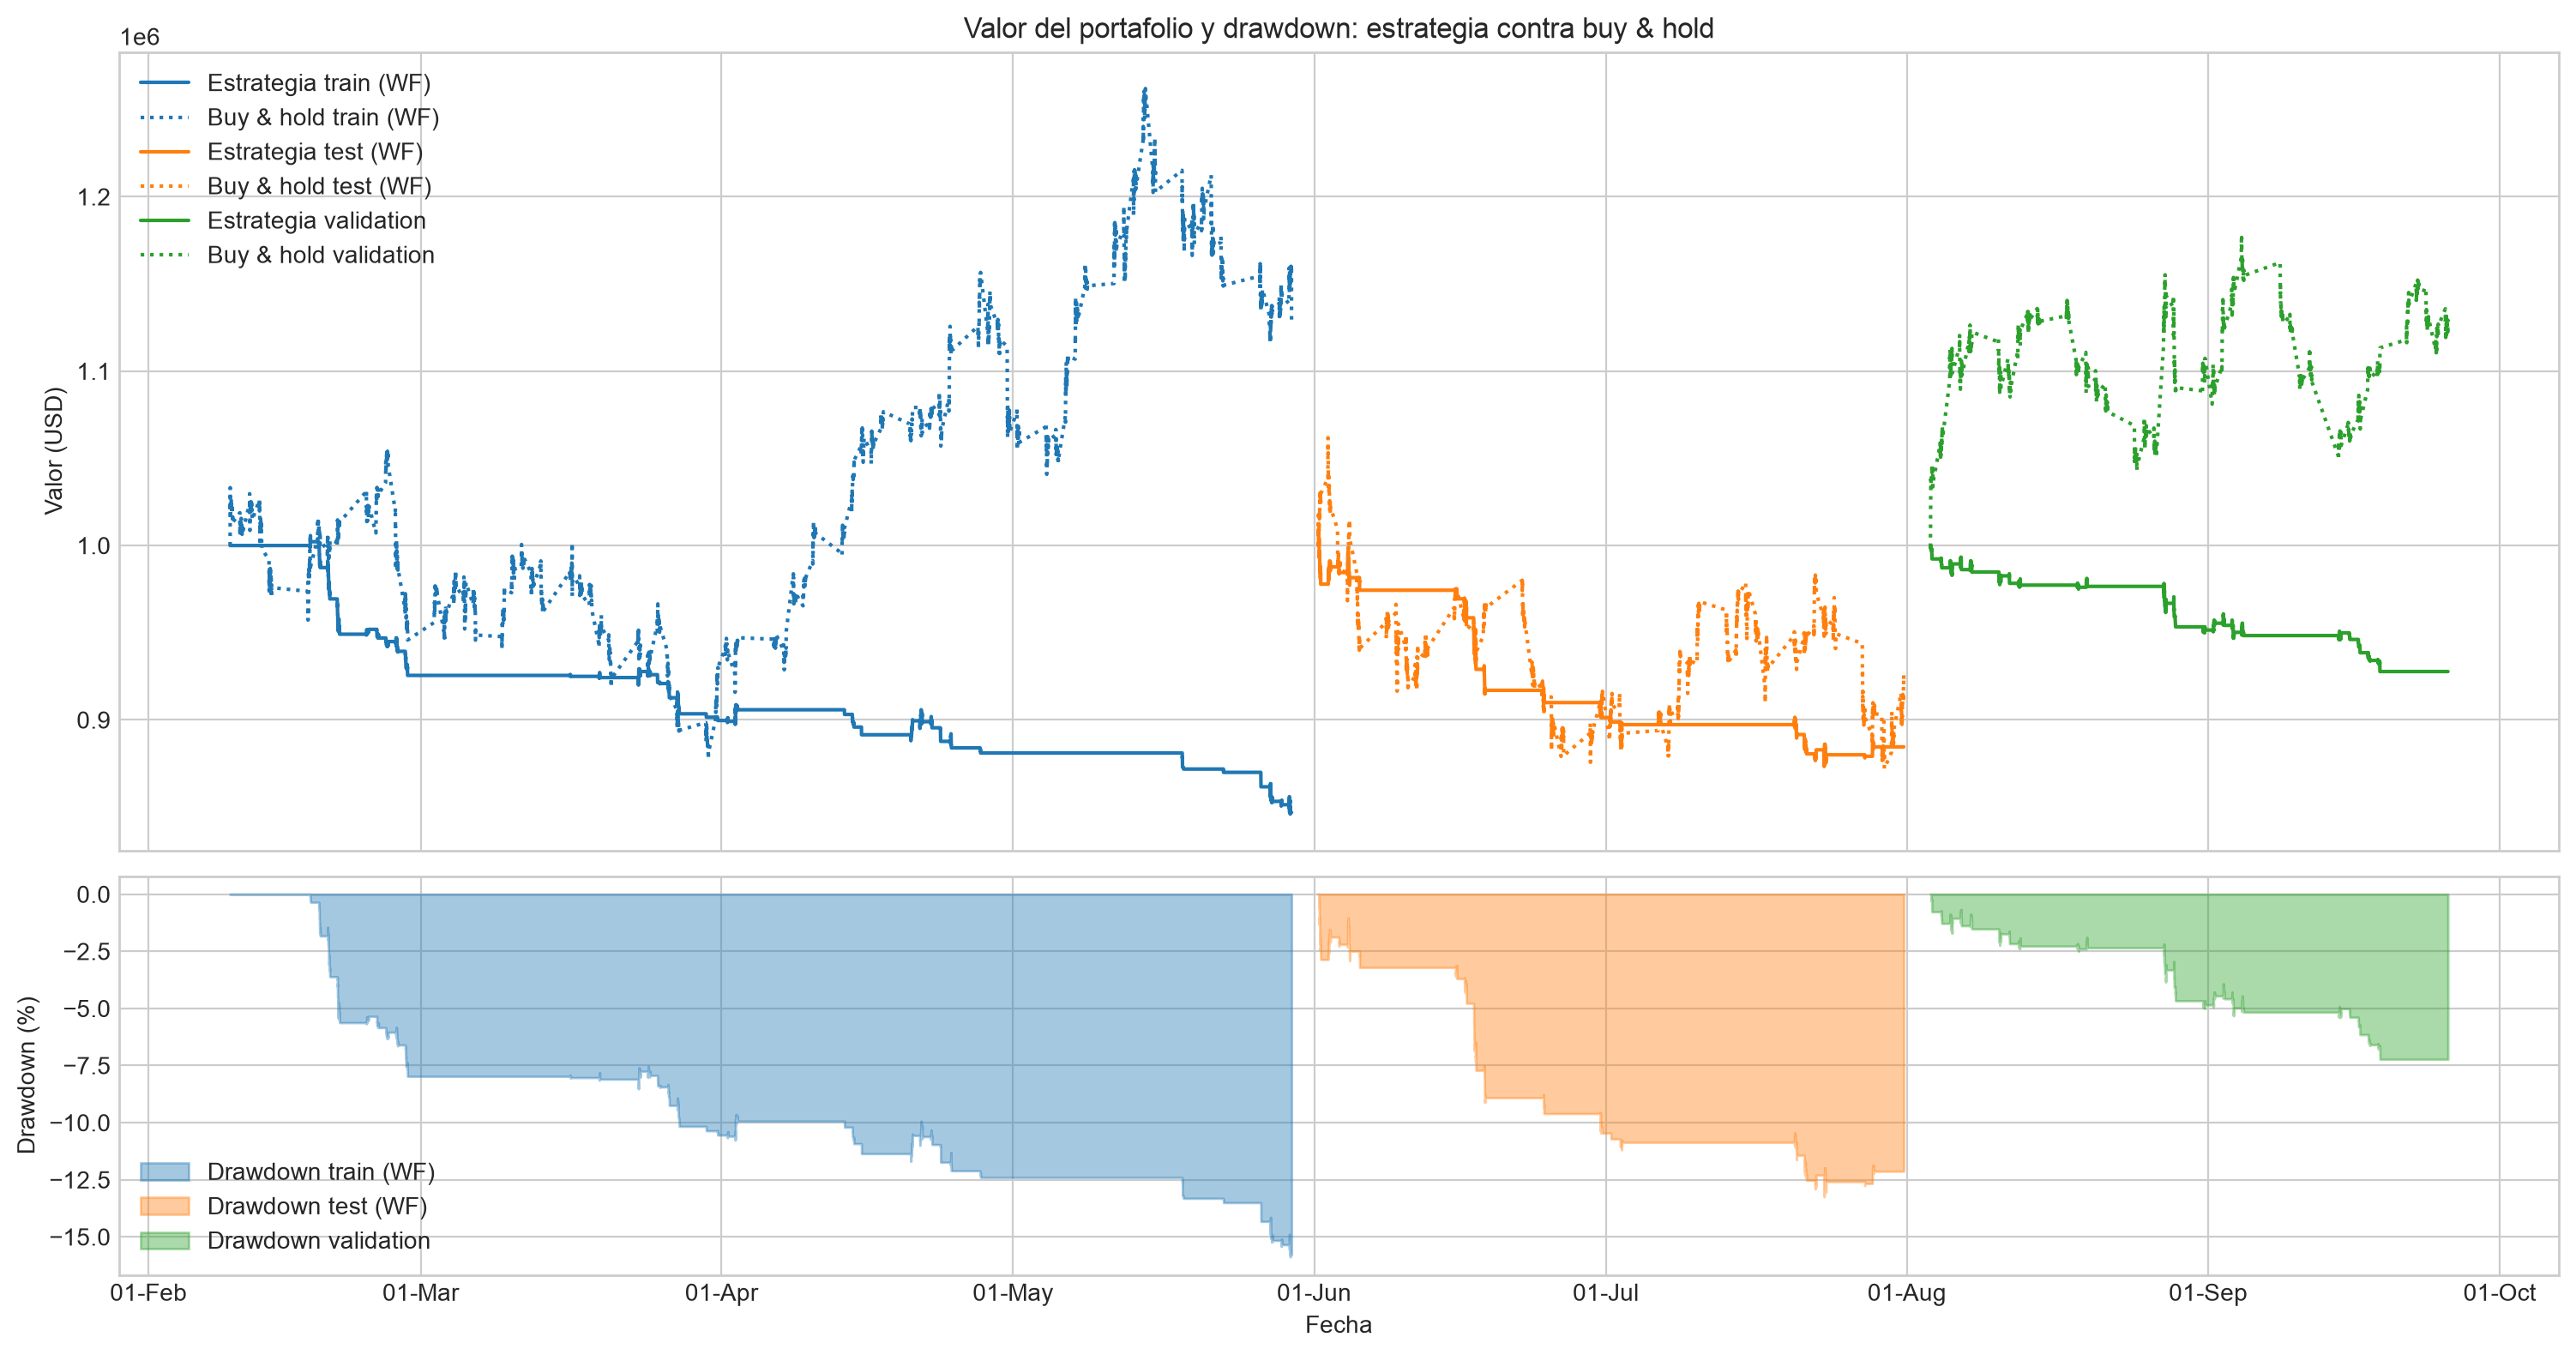

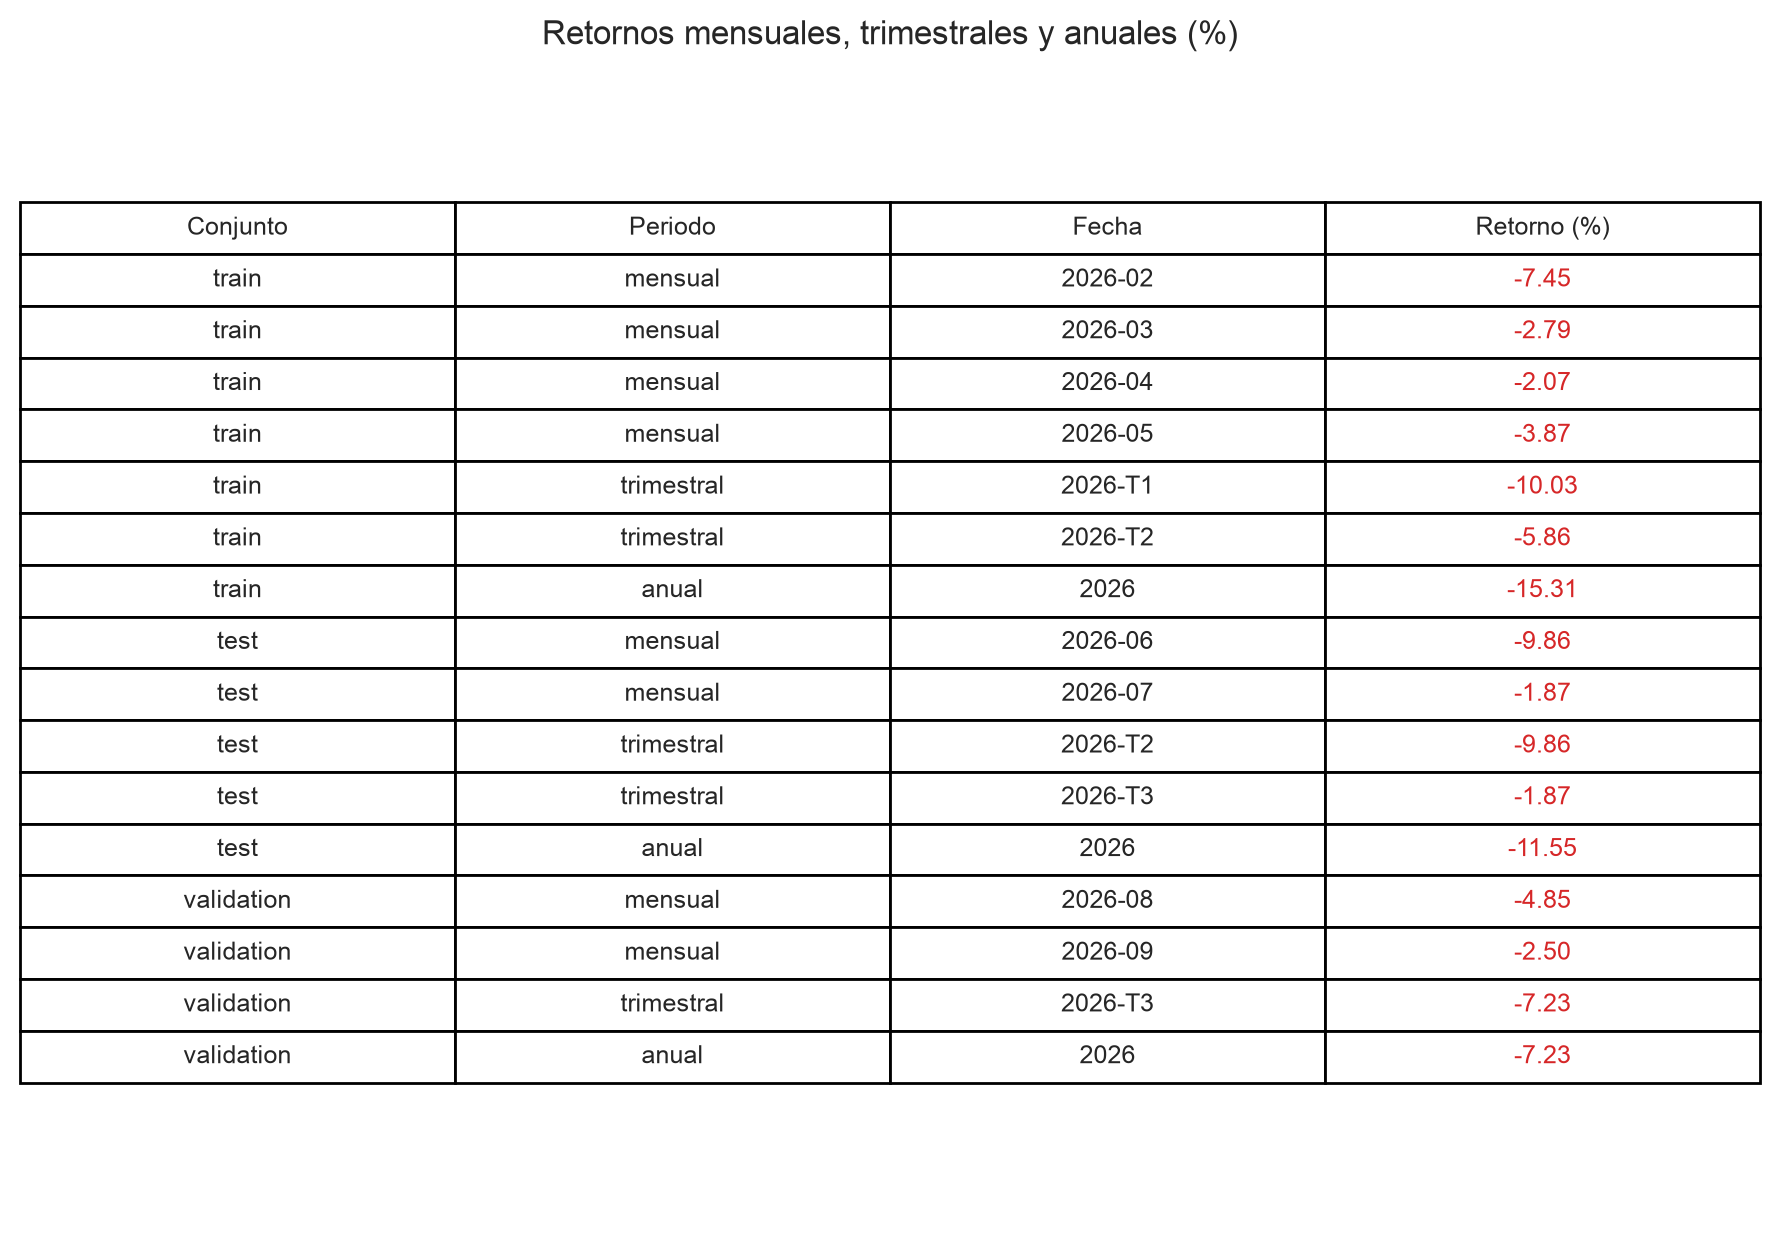

In [22]:
display(Image(FIG / "03_valor_drawdown.png"))
display(Image(FIG / "04_tabla_retornos.png"))